# Exoplot ENS — Exhaustive Backend Test Suite

This notebook systematically validates **every** public attribute, method, and edge case of the Exoplot ENS scientific engine. Each section is both a tutorial and a test : it prints expected vs. actual values, asserts correctness, and exercises error-handling paths so that any regression is caught immediately.

**Modules covered:** `constants`, `models`, `catalog`, `i18n`, `plotting`, `lightcurve`, `mcmc`, `reports`.

---
## 0. Environment Setup & Imports
Imports the full backend suite plus standard helpers (`pandas`, `numpy`, `pathlib`).  
Warnings are suppressed for a clean output; remove the filter when debugging.

In [1]:
import warnings, pathlib, pandas as pd, numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, FileLink
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')

from modules import constants
from modules.models import MassRadiusModels
from modules.catalog import ExoplanetCatalog
from modules import i18n
from modules.i18n import t, set_locale, get_locale, available_locales, available_keys, is_latex_compatible
from modules.plotting import PlotStyle, CatalogPlotter, TransitPlotter
from modules.lightcurve import LightCurveAnalyzer
from modules.mcmc import TransitFitter
from modules.reports import ReportGenerator

%matplotlib inline
print("All modules imported successfully.")

All modules imported successfully.


---
## 1. `constants.py` — Paths, Labels, Physical Constants & MCMC Config

Exhaustive check of **every** exported symbol:
- `BASE_DIR`, `DATA_DIR`, `MODELS_DIR`, `DATA_PATHS` — path resolution & existence
- `LABEL_MAP` — completeness and HTML-tag validity
- `SPECTRAL_TYPE_TEMPERATURES` — range ordering, full class list
- `HZ_*` coefficients — lengths and coefficient-array consistency
- `MODEL_CATALOG` — count, entry structure, file-existence spot-check
- `MCMC_*` and Batman constants — shapes and physical plausibility

In [ ]:
ok = lambda msg: print(f"  [PASS] {msg}")

# ── 1a. Directory Paths ──────────────────────────────────────────────
print("=" * 60)
print("1a. DIRECTORY PATHS")
print("=" * 60)
assert constants.BASE_DIR.exists(), "BASE_DIR does not exist"
ok(f"BASE_DIR = {constants.BASE_DIR}")

assert constants.DATA_DIR.exists(), "DATA_DIR does not exist"
ok(f"DATA_DIR = {constants.DATA_DIR}")

assert constants.MODELS_DIR.exists(), "MODELS_DIR does not exist"
ok(f"MODELS_DIR = {constants.MODELS_DIR}")

assert constants.DATA_DIR == constants.BASE_DIR / "data"
ok("DATA_DIR == BASE_DIR / 'data'")
assert constants.MODELS_DIR == constants.DATA_DIR / "theoretical_models"
ok("MODELS_DIR == DATA_DIR / 'theoretical_models'")

# ── 1b. DATA_PATHS ───────────────────────────────────────────────────
print("\n" + "=" * 60)
print("1b. DATA_PATHS (auto-resolved datasets)")
print("=" * 60)
assert isinstance(constants.DATA_PATHS, dict)
for key, path in constants.DATA_PATHS.items():
    exists = path.exists()
    status = "EXISTS" if exists else "MISSING (expected if dataset not downloaded)"
    print(f"  [{status}] {key} → {path.name}")

nea_path = constants.DATA_PATHS.get('NEA')
assert nea_path is not None, "NEA key missing from DATA_PATHS"
assert nea_path.suffix == '.csv'
ok(f"NEA path suffix is .csv")

# ── 1c. LABEL_MAP ────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("1c. LABEL_MAP — full inventory")
print("=" * 60)
lm = constants.LABEL_MAP
assert isinstance(lm, dict) and len(lm) > 0
ok(f"LABEL_MAP contains {len(lm)} entries")

categories = {
    "Planetary": [k for k in lm if k.startswith('pl_')],
    "Stellar":   [k for k in lm if k.startswith('st_') or k == 'hostname'],
    "System":    [k for k in lm if k.startswith('sy_')],
    "Discovery": [k for k in lm if k.startswith('disc') or k in ('discoverymethod','pl_controv_flag','ttv_flag')],
    "Coords":    [k for k in lm if k in ('ra','rastr','dec','decstr')],
}
for cat, keys in categories.items():
    print(f"  {cat:12s}: {len(keys):2d} keys  {keys[:4]}{'...' if len(keys)>4 else ''}")

for key, label in lm.items():
    assert isinstance(label, str) and len(label) > 0, f"Empty label for {key}"
ok("All labels are non-empty strings")

expected_keys = ['pl_rade','pl_bmasse','st_teff','st_rad','sy_dist','discoverymethod','pl_orbper']
for ek in expected_keys:
    assert ek in lm, f"Expected key '{ek}' missing from LABEL_MAP"
ok(f"All {len(expected_keys)} critical keys present")

# ── 1d. SPECTRAL_TYPE_TEMPERATURES ───────────────────────────────────
print("\n" + "=" * 60)
print("1d. SPECTRAL_TYPE_TEMPERATURES")
print("=" * 60)
stt = constants.SPECTRAL_TYPE_TEMPERATURES
expected_classes = ['O','B','A','F','G','K','M','L','T']
assert list(stt.keys()) == expected_classes
ok(f"All {len(expected_classes)} spectral classes present in order")

for cls, (tmin, tmax) in stt.items():
    assert tmin is None or isinstance(tmin, (int, float))
    assert tmax is None or isinstance(tmax, (int, float))
    if tmin is not None and tmax is not None:
        assert tmin < tmax, f"Inverted range for class {cls}"
    print(f"  {cls}: Teff ∈ [{tmin}, {tmax}]")
ok("All temperature ranges are correctly ordered")

# ── 1e. Habitable Zone Coefficients ──────────────────────────────────
print("\n" + "=" * 60)
print("1e. HABITABLE ZONE COEFFICIENTS")
print("=" * 60)
n_hz = len(constants.HZ_NAMES)
ok(f"HZ_NAMES: {n_hz} models → {constants.HZ_NAMES}")

for arr_name in ('HZ_SEFF_SUN', 'HZ_A', 'HZ_B', 'HZ_C', 'HZ_D'):
    arr = getattr(constants, arr_name)
    assert len(arr) == n_hz, f"{arr_name} has {len(arr)} entries, expected {n_hz}"
ok(f"All 5 coefficient arrays have consistent length ({n_hz})")

assert all(s > 0 for s in constants.HZ_SEFF_SUN)
ok("HZ_SEFF_SUN values are all positive")

# ── 1f. MODEL_CATALOG ────────────────────────────────────────────────
print("\n" + "=" * 60)
print("1f. MODEL_CATALOG — structure & file-existence spot-check")
print("=" * 60)
mc = constants.MODEL_CATALOG
ok(f"Total models registered: {len(mc)}")

for key, info in mc.items():
    assert isinstance(info, tuple) and len(info) >= 2
    assert isinstance(info[0], str) and isinstance(info[1], str)
ok("Every entry is a tuple (filename, label[, options])")

spot_checks = ['zeng_rocky', 'zeng_iron', 'zeng_earth', 'marcus_collision',
               'Water World', 'luo_2024', 'aguichine_2021', 'aguichine_2025',
               'tang_2025', 'LF_1Gyr_solar', 'zeng_1h2_700K', 'zeng_50h2o_300K']
for k in spot_checks:
    assert k in mc, f"Expected key '{k}' not in MODEL_CATALOG"
    fpath = constants.MODELS_DIR / mc[k][0]
    exists = fpath.exists()
    print(f"  {'EXISTS' if exists else 'MISS ':5s}  {k:30s} → {mc[k][1]}")

# ── 1g. MCMC & Batman Constants ──────────────────────────────────────
print("\n" + "=" * 60)
print("1g. MCMC & BATMAN TRANSIT CONSTANTS")
print("=" * 60)
assert len(constants.MCMC_LABELS) == 4
ok(f"MCMC_LABELS ({len(constants.MCMC_LABELS)}): {constants.MCMC_LABELS}")

# MCMC_BOUNDS / MCMC_X0 were removed from constants.py: the legacy
# defaults were both inconsistent (x0 outside bounds) and dangerously
# narrow (a/Rs locked to [4, 4.2]).  TransitFitter now uses its
# data-driven `_estimate_bounds` whenever the caller does not supply
# `custom_bounds` / `custom_x0`, and raises a clear error otherwise.
assert not hasattr(constants, "MCMC_BOUNDS"), \
    "MCMC_BOUNDS should no longer exist in constants.py"
assert not hasattr(constants, "MCMC_X0"), \
    "MCMC_X0 should no longer exist in constants.py"
ok("MCMC_BOUNDS / MCMC_X0 removed (data-driven defaults only)")

assert len(constants.LIMB_DARKENING_COEFFS) == 2
ok(f"Limb darkening: model={constants.LIMB_DARKENING_MODEL}, coeffs={constants.LIMB_DARKENING_COEFFS}")

assert constants.ECCENTRICITY == 0.0
assert constants.ARG_PERI == 90.0
ok(f"Eccentricity={constants.ECCENTRICITY}, ω={constants.ARG_PERI}°")

print("\n✓ constants.py — all checks passed.")

---
## 2. `models.py` — `MassRadiusModels` Class

Exhaustive validation:
- Instance attributes (`catalog`, `models_directory`) and `__repr__`
- `list_available_models()` — returns a copy, correct count
- `get_model_label()` — known key, unknown key fallback
- `get_model_curve()` — loads multiple model families (whitespace-delimited, CSV with header, different `usecols`), verifies DataFrame schema, dtypes, no NaN, positive values
- Error paths: `KeyError` for invalid key, `FileNotFoundError` for missing file

In [3]:
ok = lambda msg: print(f"  [PASS] {msg}")

mr = MassRadiusModels()

# ── 2a. Instance attributes ──────────────────────────────────────────
print("=" * 60)
print("2a. INSTANCE ATTRIBUTES & __repr__")
print("=" * 60)
assert isinstance(mr.catalog, dict) and len(mr.catalog) > 0
ok(f"catalog: {len(mr.catalog)} entries")

assert mr.models_directory.exists()
ok(f"models_directory exists: {mr.models_directory}")

r = repr(mr)
assert "MassRadiusModels" in r and "n_models=" in r
ok(f"__repr__ → {r}")

# ── 2b. list_available_models() ──────────────────────────────────────
print("\n" + "=" * 60)
print("2b. list_available_models()")
print("=" * 60)
catalog_copy = mr.list_available_models()
assert catalog_copy == mr.catalog
assert catalog_copy is not mr.catalog, "Should return a copy, not the original"
ok(f"Returns a copy with {len(catalog_copy)} entries")

# ── 2c. get_model_label() ────────────────────────────────────────────
print("\n" + "=" * 60)
print("2c. get_model_label()")
print("=" * 60)
test_labels = {
    'zeng_rocky': "Zeng+2019: Pure Rock",
    'zeng_iron': "Zeng+2019: Pure Iron",
    'zeng_earth': "Zeng+2019: Earth-like",
    'marcus_collision': "Marcus+2010: Collision",
    'Water World': "Water World: 650K",
    'luo_2024': "Luo 2024",
    'LF_1Gyr_solar': "L&F 2014: 1Gyr (Solar)",
    'zeng_1h2_700K': "Zeng+2019: 1% H₂ @ 700K",
    'zeng_50h2o_300K': "Zeng+2019: 50% H₂O @ 300K",
}
for key, expected in test_labels.items():
    got = mr.get_model_label(key)
    assert got == expected, f"Label mismatch for '{key}': got '{got}'"
    print(f"  {key:25s} → {got}")
ok(f"All {len(test_labels)} labels correct")

unknown_label = mr.get_model_label("nonexistent_model_xyz")
assert unknown_label == "nonexistent_model_xyz", "Unknown key should return key itself"
ok(f"Unknown key fallback → '{unknown_label}'")

# ── 2d. get_model_curve() — multiple families ────────────────────────
print("\n" + "=" * 60)
print("2d. get_model_curve() — loading diverse file formats")
print("=" * 60)

test_keys = [
    'zeng_earth',          # whitespace-delimited, no header
    'zeng_iron',           # whitespace-delimited, no header
    'zeng_rocky',          # whitespace-delimited, no header
    'marcus_collision',    # whitespace-delimited, no header
    'zeng_2016_20fe',      # whitespace-delimited, no header
    'Water World',         # .txt with header, usecols [0,1]
    'luo_2024',            # .txt with header, usecols [0,1]
    'aguichine_2021',      # header, usecols [4,6]
    'aguichine_2025',      # .dat, header, usecols [3,6]
    'tang_2025',           # .dat, header, usecols [3,6]
    'LF_100Myr_solar',     # Lopez & Fortney
    'LF_10Gyr_enhanced',   # Lopez & Fortney
    'zeng_0.1h2_300K',     # dynamic H₂ model
    'zeng_5h2_2000K',      # dynamic H₂ model
    'zeng_50h2o_300K',     # dynamic H₂O model
    'zeng_100h2o_1000K',   # dynamic H₂O model
]

loaded_count = 0
for key in test_keys:
    try:
        df = mr.get_model_curve(key)
        assert list(df.columns) == ['mass', 'radius'], f"Wrong columns for {key}"
        assert df.dtypes['mass'] == np.float64 or np.issubdtype(df.dtypes['mass'], np.floating)
        assert df.dtypes['radius'] == np.float64 or np.issubdtype(df.dtypes['radius'], np.floating)
        assert df.isna().sum().sum() == 0, f"NaN values found in {key}"
        assert len(df) > 0, f"Empty DataFrame for {key}"
        assert (df['mass'] > 0).all() and (df['radius'] > 0).all(), f"Non-positive values in {key}"
        loaded_count += 1
        print(f"  OK  {key:25s}  →  {len(df):3d} rows,  mass ∈ [{df['mass'].min():.4f}, {df['mass'].max():.1f}]")
    except FileNotFoundError:
        print(f"  SKIP {key:25s}  →  data file not present")
    except Exception as e:
        print(f"  FAIL {key:25s}  →  {e}")

ok(f"{loaded_count}/{len(test_keys)} models loaded and validated")

# ── 2e. Error handling ────────────────────────────────────────────────
print("\n" + "=" * 60)
print("2e. ERROR HANDLING")
print("=" * 60)

try:
    mr.get_model_curve("this_key_does_not_exist")
    assert False, "Should have raised KeyError"
except KeyError as e:
    ok(f"KeyError for invalid key: {e}")

print("\n✓ models.py — all checks passed.")

2a. INSTANCE ATTRIBUTES & __repr__
  [PASS] catalog: 50 entries
  [PASS] models_directory exists: /Users/simon.wtmn/Desktop/Exoplot_ENS/data/theoretical_models
  [PASS] __repr__ → MassRadiusModels(n_models=50, dir='/Users/simon.wtmn/Desktop/Exoplot_ENS/data/theoretical_models')

2b. list_available_models()
  [PASS] Returns a copy with 50 entries

2c. get_model_label()
  zeng_rocky                → Zeng+2019: Pure Rock
  zeng_iron                 → Zeng+2019: Pure Iron
  zeng_earth                → Zeng+2019: Earth-like
  marcus_collision          → Marcus+2010: Collision
  Water World               → Water World: 650K
  luo_2024                  → Luo 2024
  LF_1Gyr_solar             → L&F 2014: 1Gyr (Solar)
  zeng_1h2_700K             → Zeng+2019: 1% H₂ @ 700K
  zeng_50h2o_300K           → Zeng+2019: 50% H₂O @ 300K
  [PASS] All 9 labels correct
  [PASS] Unknown key fallback → 'nonexistent_model_xyz'

2d. get_model_curve() — loading diverse file formats
  OK  zeng_earth                

---
## 3. `catalog.py` — `ExoplanetCatalog` Class

Exhaustive validation:
- **Instantiation**: default `NEA`, invalid dataset error, `custom_path`
- **Attributes**: `name`, `original_df`, `df`, `__repr__`
- **`reset()` / `get_data()`**: round-trip integrity
- **Every filter method tested individually** with observable row-count reduction:
  - `filter_discovery` (mission, method, year_min/max, kp_max)
  - `filter_stellar` (st_type, teff, lum, met, age, rad, rad_err)
  - `filter_spectral_type` (explicit + temperature fallback)
  - `filter_planet` (rade, mass, density, eqt, tdyson, SNR error filters)
  - `filter_orbit` (distance, eccentricity, transit_depth, period, impact_param)
  - `filter_system` (multiplicity)
  - `filter_fulton_gap` (main-sequence stellar envelope)
- **Method chaining**: full pipeline
- **Edge cases**: `_apply_range` min>max error, missing columns silently ignored

In [4]:
ok = lambda msg: print(f"  [PASS] {msg}")

# ── 3a. Instantiation & Attributes ───────────────────────────────────
print("=" * 60)
print("3a. INSTANTIATION & ATTRIBUTES")
print("=" * 60)

cat = ExoplanetCatalog(dataset_name='NEA')
N = len(cat.original_df)

assert cat.name == 'NEA'
ok(f"name = '{cat.name}'")

assert isinstance(cat.original_df, pd.DataFrame) and len(cat.original_df) > 0
ok(f"original_df loaded: {cat.original_df.shape}")

assert isinstance(cat.df, pd.DataFrame) and len(cat.df) == N
ok(f"df starts as full copy: {cat.df.shape}")

assert cat.df is not cat.original_df, "df should be a copy, not the original"
ok("df is a distinct copy from original_df")

r = repr(cat)
assert "ExoplanetCatalog" in r and cat.name in r
ok(f"__repr__ → {r}")

# ── 3b. Error on invalid dataset ─────────────────────────────────────
print("\n" + "=" * 60)
print("3b. ERROR HANDLING — invalid dataset")
print("=" * 60)
try:
    ExoplanetCatalog(dataset_name='NONEXISTENT')
    assert False, "Should have raised FileNotFoundError"
except FileNotFoundError as e:
    ok(f"FileNotFoundError for invalid dataset: {e}")

# ── 3c. reset() and get_data() ───────────────────────────────────────
print("\n" + "=" * 60)
print("3c. reset() & get_data()")
print("=" * 60)
cat.df = cat.df.head(5)
assert len(cat.df) == 5
ok("Manually reduced df to 5 rows")

ret = cat.reset()
assert ret is cat, "reset() should return self for chaining"
assert len(cat.df) == N
ok(f"reset() restored df to {N} rows")

gd = cat.get_data()
assert isinstance(gd, pd.DataFrame)
assert list(gd.index) == list(range(len(gd))), "get_data() should reset index"
ok("get_data() returns clean-indexed DataFrame")

# ── 3d. _apply_range edge cases ──────────────────────────────────────
print("\n" + "=" * 60)
print("3d. _apply_range — edge cases")
print("=" * 60)
cat.reset()
try:
    cat._apply_range('pl_rade', 10, 1)
    assert False, "Should have raised ValueError"
except ValueError as e:
    ok(f"ValueError when min > max: {e}")

cat.reset()
before = len(cat.df)
cat._apply_range('column_that_does_not_exist', 0, 100)
assert len(cat.df) == before
ok("Missing column silently ignored (no crash, no row loss)")

# ── 3e. filter_discovery — each parameter ────────────────────────────
print("\n" + "=" * 60)
print("3e. filter_discovery()")
print("=" * 60)

cat.reset()
ret = cat.filter_discovery(mission='Kepler')
assert ret is cat
n_kepler = len(cat.df)
assert n_kepler < N
ok(f"mission='Kepler': {N} → {n_kepler} rows")

cat.reset()
cat.filter_discovery(method='Transit')
n_transit = len(cat.df)
assert n_transit < N
ok(f"method='Transit': {N} → {n_transit} rows")

cat.reset()
cat.filter_discovery(year_min=2020)
n_recent = len(cat.df)
assert n_recent < N
ok(f"year_min=2020: {N} → {n_recent} rows")

cat.reset()
cat.filter_discovery(year_max=2015)
n_old = len(cat.df)
assert n_old < N
ok(f"year_max=2015: {N} → {n_old} rows")

cat.reset()
cat.filter_discovery(kp_max=12)
n_bright = len(cat.df)
assert n_bright < N
ok(f"kp_max=12: {N} → {n_bright} rows")

# ── 3f. filter_stellar — each parameter ──────────────────────────────
print("\n" + "=" * 60)
print("3f. filter_stellar()")
print("=" * 60)

cat.reset()
cat.filter_stellar(st_type='G')
n_g = len(cat.df)
assert n_g < N
ok(f"st_type='G': {N} → {n_g} rows")

cat.reset()
cat.filter_stellar(teff_min=5000, teff_max=6000)
n_teff = len(cat.df)
assert n_teff < N
ok(f"teff=[5000,6000]: {N} → {n_teff} rows")

cat.reset()
cat.filter_stellar(met_min=-0.5, met_max=0.5)
n_met = len(cat.df)
assert n_met < N
ok(f"met=[-0.5,0.5]: {N} → {n_met} rows")

cat.reset()
cat.filter_stellar(age_min=1, age_max=10)
n_age = len(cat.df)
assert n_age < N
ok(f"age=[1,10]: {N} → {n_age} rows")

cat.reset()
cat.filter_stellar(rad_min=0.5, rad_max=1.5)
n_rad = len(cat.df)
assert n_rad < N
ok(f"rad=[0.5,1.5]: {N} → {n_rad} rows")

# ── 3g. filter_spectral_type — string match + Teff fallback ──────────
print("\n" + "=" * 60)
print("3g. filter_spectral_type()")
print("=" * 60)

for sclass in ['G', 'K', 'M']:
    cat.reset()
    cat.filter_spectral_type(sclass)
    n_cls = len(cat.df)
    assert n_cls < N
    ok(f"Spectral class '{sclass}': {N} → {n_cls} rows")

cat.reset()
cat.filter_spectral_type('m')
n_lower = len(cat.df)
cat.reset()
cat.filter_spectral_type('M')
n_upper = len(cat.df)
assert n_lower == n_upper
ok("Case-insensitive: 'm' == 'M'")

# ── 3h. filter_planet — each parameter ───────────────────────────────
print("\n" + "=" * 60)
print("3h. filter_planet()")
print("=" * 60)

cat.reset()
cat.filter_planet(rade_min=1, rade_max=4)
n_rade = len(cat.df)
assert n_rade < N
ok(f"rade=[1,4]: {N} → {n_rade} rows")

cat.reset()
cat.filter_planet(mass_min=1, mass_max=50)
n_mass = len(cat.df)
assert n_mass < N
ok(f"mass=[1,50]: {N} → {n_mass} rows")

cat.reset()
cat.filter_planet(density_min=1, density_max=10)
n_dens = len(cat.df)
assert n_dens < N
ok(f"density=[1,10]: {N} → {n_dens} rows")

cat.reset()
cat.filter_planet(eqt_min=200, eqt_max=500)
n_eqt = len(cat.df)
assert n_eqt < N
ok(f"eqt=[200,500]: {N} → {n_eqt} rows")

cat.reset()
assert 'pl_tdyson' not in cat.df.columns
cat.filter_planet(tdyson_min=200, tdyson_max=800)
n_tdyson = len(cat.df)
assert n_tdyson < N
assert 'pl_tdyson' not in cat.df.columns, "tdyson should not persist as a column"
ok(f"tdyson=[200,800]: {N} → {n_tdyson} rows (no side-effect column)")

# ── 3i. filter_orbit — each parameter ────────────────────────────────
print("\n" + "=" * 60)
print("3i. filter_orbit()")
print("=" * 60)

cat.reset()
cat.filter_orbit(distance_min=0.01, distance_max=1.0)
n_orb = len(cat.df)
assert n_orb < N
ok(f"distance=[0.01,1.0] AU: {N} → {n_orb} rows")

cat.reset()
cat.filter_orbit(eccentricity_max=0.1)
n_ecc = len(cat.df)
assert n_ecc < N
ok(f"eccentricity_max=0.1: {N} → {n_ecc} rows")

cat.reset()
cat.filter_orbit(period_max=10)
n_per = len(cat.df)
assert n_per < N
ok(f"period_max=10 d: {N} → {n_per} rows")

# ── 3j. filter_system ────────────────────────────────────────────────
print("\n" + "=" * 60)
print("3j. filter_system()")
print("=" * 60)

cat.reset()
cat.filter_system(multiplicity_min=3)
n_multi = len(cat.df)
assert n_multi < N
ok(f"multiplicity_min=3: {N} → {n_multi} rows")

cat.reset()
cat.filter_system(multiplicity_max=1)
n_single = len(cat.df)
assert n_single < N
ok(f"multiplicity_max=1: {N} → {n_single} rows")

# ── 3k. filter_fulton_gap ────────────────────────────────────────────
print("\n" + "=" * 60)
print("3k. filter_fulton_gap()")
print("=" * 60)

cat.reset()
ret = cat.filter_fulton_gap()
assert ret is cat
n_fg = len(cat.df)
assert n_fg <= N
ok(f"filter_fulton_gap: {N} → {n_fg} rows (removed {N - n_fg} evolved stars)")

# ── 3l. Full method chaining pipeline ────────────────────────────────
print("\n" + "=" * 60)
print("3l. FULL METHOD CHAINING PIPELINE")
print("=" * 60)

cat.reset()
result = (cat
    .filter_discovery(mission='Kepler', year_min=2010, year_max=2024, kp_max=16)
    .filter_stellar(st_type='M', teff_min=2500, teff_max=4000, rad_max=0.6)
    .filter_spectral_type('M')
    .filter_planet(mass_max=20, rade_max=3.0, eqt_max=1000)
    .filter_orbit(period_max=50, eccentricity_max=0.5)
    .filter_system(multiplicity_min=1)
    .filter_fulton_gap()
    .get_data()
)
assert isinstance(result, pd.DataFrame)
assert len(result) < N
ok(f"Chained pipeline: {N} → {len(result)} rows")
display(result[['pl_name', 'hostname', 'pl_bmasse', 'pl_rade']].head(5))

cat.reset()
assert len(cat.df) == N
ok(f"Final reset confirmed: {N} rows restored")

print(f"\n✓ catalog.py — all checks passed.")

3a. INSTANTIATION & ATTRIBUTES
  [PASS] name = 'NEA'
  [PASS] original_df loaded: (6128, 219)
  [PASS] df starts as full copy: (6128, 219)
  [PASS] df is a distinct copy from original_df
  [PASS] __repr__ → ExoplanetCatalog(name='NEA', rows=6128/6128, cols=219)

3b. ERROR HANDLING — invalid dataset
  [PASS] FileNotFoundError for invalid dataset: Dataset 'NONEXISTENT' not found at None

3c. reset() & get_data()
  [PASS] Manually reduced df to 5 rows
  [PASS] reset() restored df to 6128 rows
  [PASS] get_data() returns clean-indexed DataFrame

3d. _apply_range — edge cases
  [PASS] ValueError when min > max: Min value (10) cannot be greater than max value (1)
  [PASS] Missing column silently ignored (no crash, no row loss)

3e. filter_discovery()
  [PASS] mission='Kepler': 6128 → 2783 rows
  [PASS] method='Transit': 6128 → 3319 rows
  [PASS] year_min=2020: 6128 → 643 rows
  [PASS] year_max=2015: 6128 → 1118 rows
  [PASS] kp_max=12: 6128 → 383 rows

3f. filter_stellar()
  [PASS] st_type='

,pl_name,hostname,pl_bmasse,pl_rade
0,Kepler-125 b,Kepler-125,6.21,2.37
1,Kepler-125 c,Kepler-125,0.33,0.74
2,Kepler-138 b,Kepler-138,0.07,0.64
3,Kepler-138 c,Kepler-138,2.30,1.51
4,Kepler-138 d,Kepler-138,2.10,1.51


  [PASS] Final reset confirmed: 6128 rows restored

✓ catalog.py — all checks passed.


---
## 4. `i18n.py` — Internationalisation Module

Exhaustive validation:
- `available_locales()` — all 9 locales present
- `available_keys()` — sorted, matches English reference
- `set_locale()` / `get_locale()` — round-trip, error on invalid code
- `t()` — default locale, explicit override, `**kwargs` interpolation, unknown key fallback, fallback to English for missing keys
- `is_latex_compatible()` — True for Latin-script locales, False for CJK/Cyrillic
- LaTeX mode (`latex=True`) — Unicode → LaTeX replacement

In [5]:
ok = lambda msg: print(f"  [PASS] {msg}")

# ── 4a. available_locales() ───────────────────────────────────────────
print("=" * 60)
print("4a. available_locales()")
print("=" * 60)
locales = available_locales()
expected = ['en', 'fr', 'es', 'de', 'ja', 'zh', 'ru', 'pt', 'ko']
assert locales == expected
ok(f"{len(locales)} locales: {locales}")

# ── 4b. available_keys() ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("4b. available_keys()")
print("=" * 60)
keys = available_keys()
assert isinstance(keys, list) and len(keys) > 0
assert keys == sorted(keys), "Keys should be sorted"
ok(f"{len(keys)} translation keys")
print(f"  First 5: {keys[:5]}")
print(f"  Last 5:  {keys[-5:]}")

# ── 4c. set_locale() / get_locale() ──────────────────────────────────
print("\n" + "=" * 60)
print("4c. set_locale() / get_locale()")
print("=" * 60)
set_locale("en")
assert get_locale() == "en"
ok("set_locale('en') → get_locale() == 'en'")

set_locale("fr")
assert get_locale() == "fr"
ok("set_locale('fr') → get_locale() == 'fr'")

for loc in locales:
    set_locale(loc)
    assert get_locale() == loc
ok(f"Round-trip verified for all {len(locales)} locales")

try:
    set_locale("xx_invalid")
    assert False, "Should have raised ValueError"
except ValueError as e:
    ok(f"ValueError for invalid locale: {e}")

set_locale("en")

# ── 4d. t() — basic translation ──────────────────────────────────────
print("\n" + "=" * 60)
print("4d. t() — basic translation")
print("=" * 60)
set_locale("en")
assert t("report_title") == "Transit Analysis Report"
ok(f"t('report_title') [en] → '{t('report_title')}'")

set_locale("fr")
assert t("report_title") == "Rapport d'Analyse de Transit"
ok(f"t('report_title') [fr] → '{t('report_title')}'")

# Explicit locale override
set_locale("en")
assert t("report_title", locale="de") == "Transit-Analysebericht"
ok(f"t('report_title', locale='de') → '{t('report_title', locale='de')}'")

# ── 4e. t() — kwargs interpolation ───────────────────────────────────
print("\n" + "=" * 60)
print("4e. t() — kwargs interpolation")
print("=" * 60)
set_locale("en")
result = t("generated_by", name="Exoplot")
assert result == "Generated by Exoplot"
ok(f"generated_by(name='Exoplot') → '{result}'")

result = t("section_transit_fit", period=1.2345)
assert "1.2345" in result
ok(f"section_transit_fit(period=1.2345) → '{result}'")

result = t("target_label", target="WASP-76 b")
assert "WASP-76 b" in result
ok(f"target_label(target='WASP-76 b') → '{result}'")

# ── 4f. t() — unknown key fallback ───────────────────────────────────
print("\n" + "=" * 60)
print("4f. t() — unknown key fallback")
print("=" * 60)
result = t("nonexistent_key_xyz")
assert result == "nonexistent_key_xyz"
ok(f"Unknown key returns itself: '{result}'")

# ── 4g. t() — cross-locale completeness ──────────────────────────────
print("\n" + "=" * 60)
print("4g. CROSS-LOCALE COMPLETENESS CHECK")
print("=" * 60)
set_locale("en")
ref_keys = available_keys()
for loc in locales:
    for key in ref_keys:
        val = t(key, locale=loc)
        assert isinstance(val, str) and len(val) > 0, f"Empty/missing: {loc}/{key}"
ok(f"All {len(ref_keys)} keys × {len(locales)} locales produce non-empty strings")

# ── 4h. is_latex_compatible() ─────────────────────────────────────────
print("\n" + "=" * 60)
print("4h. is_latex_compatible()")
print("=" * 60)
latex_ok = ['en', 'fr', 'es', 'de', 'pt']
latex_no = ['ja', 'zh', 'ko', 'ru']

for loc in latex_ok:
    assert is_latex_compatible(loc) is True
ok(f"LaTeX-compatible: {latex_ok}")

for loc in latex_no:
    assert is_latex_compatible(loc) is False
ok(f"LaTeX-incompatible: {latex_no}")

# ── 4i. LaTeX mode ───────────────────────────────────────────────────
print("\n" + "=" * 60)
print("4i. t(latex=True) — Unicode → LaTeX replacement")
print("=" * 60)
set_locale("en")
raw = t("col_value")
latex_result = t("col_value", latex=True)
assert "±" in raw
assert r"$\pm$" in latex_result
ok(f"raw: '{raw}' → latex: '{latex_result}'")

raw_tau = t("autocorr")
latex_tau = t("autocorr", latex=True)
assert "τ" in raw_tau
assert r"$\tau$" in latex_tau
ok(f"raw: '{raw_tau}' → latex: '{latex_tau}'")

set_locale("en")
print(f"\n✓ i18n.py — all checks passed.")

4a. available_locales()
  [PASS] 9 locales: ['en', 'fr', 'es', 'de', 'ja', 'zh', 'ru', 'pt', 'ko']

4b. available_keys()
  [PASS] 37 translation keys
  First 5: ['a_rs_label', 'acceptance', 'autocorr', 'best_period_label', 'burn_in']
  Last 5:  ['spaghetti_label', 'step_number', 'target_label', 'time_bjd', 'transit_depth_ppm']

4c. set_locale() / get_locale()
  [PASS] set_locale('en') → get_locale() == 'en'
  [PASS] set_locale('fr') → get_locale() == 'fr'
  [PASS] Round-trip verified for all 9 locales
  [PASS] ValueError for invalid locale: Unknown locale 'xx_invalid'. Supported: en, fr, es, de, ja, zh, ru, pt, ko

4d. t() — basic translation
  [PASS] t('report_title') [en] → 'Transit Analysis Report'
  [PASS] t('report_title') [fr] → 'Rapport d'Analyse de Transit'
  [PASS] t('report_title', locale='de') → 'Transit-Analysebericht'

4e. t() — kwargs interpolation
  [PASS] generated_by(name='Exoplot') → 'Generated by Exoplot'
  [PASS] section_transit_fit(period=1.2345) → 'Phase-Folded Tr

---
## 5. `plotting.py` — Catalog Visualization (Matplotlib)

Exhaustive validation of `PlotStyle` and `CatalogPlotter`:
- **`PlotStyle`**: `configure()`, `get_label()` (HTML→mathtext), `polish()`, `_ensure_configured()`
- **`CatalogPlotter`**: `__repr__`, `model_loader` attribute
  - `plot_scatter()` — basic, with `color_by`, `highlight_planets`, `overlay_models`, log scales
  - `plot_density()` — Gaussian-smoothed 2D heatmap, log axes, point overlay toggle
  - `plot_histogram()` — linear and log-x binning, custom color
- All methods return `(fig, ax)` tuples; figures are verified and closed after checks

5a. PlotStyle
  [PASS] configure() sets _configured flag
  [PASS] LaTeX enabled by default (usetex=True)
  [PASS] DPI = 500 (figure + savefig)
  [PASS] Font: Computer Modern Roman
  [PASS] LaTeX preamble includes Unicode declarations
  [PASS] get_label('pl_orbeccen') → 'Eccentricity'
  [PASS] get_label('pl_rade') HTML→LaTeX → 'Planet Radius [R$_{⊕}$]'
  [PASS] get_label unknown key → passthrough 'nonexistent_column'
  [PASS] polish() applies grid and minorticks without error

5b. CatalogPlotter — instance
  [PASS] model_loader is MassRadiusModels
  [PASS] __repr__ → CatalogPlotter(backend='matplotlib')

5c. plot_scatter() — basic
  [PASS] Basic scatter: [7.  5.5], log-log axes


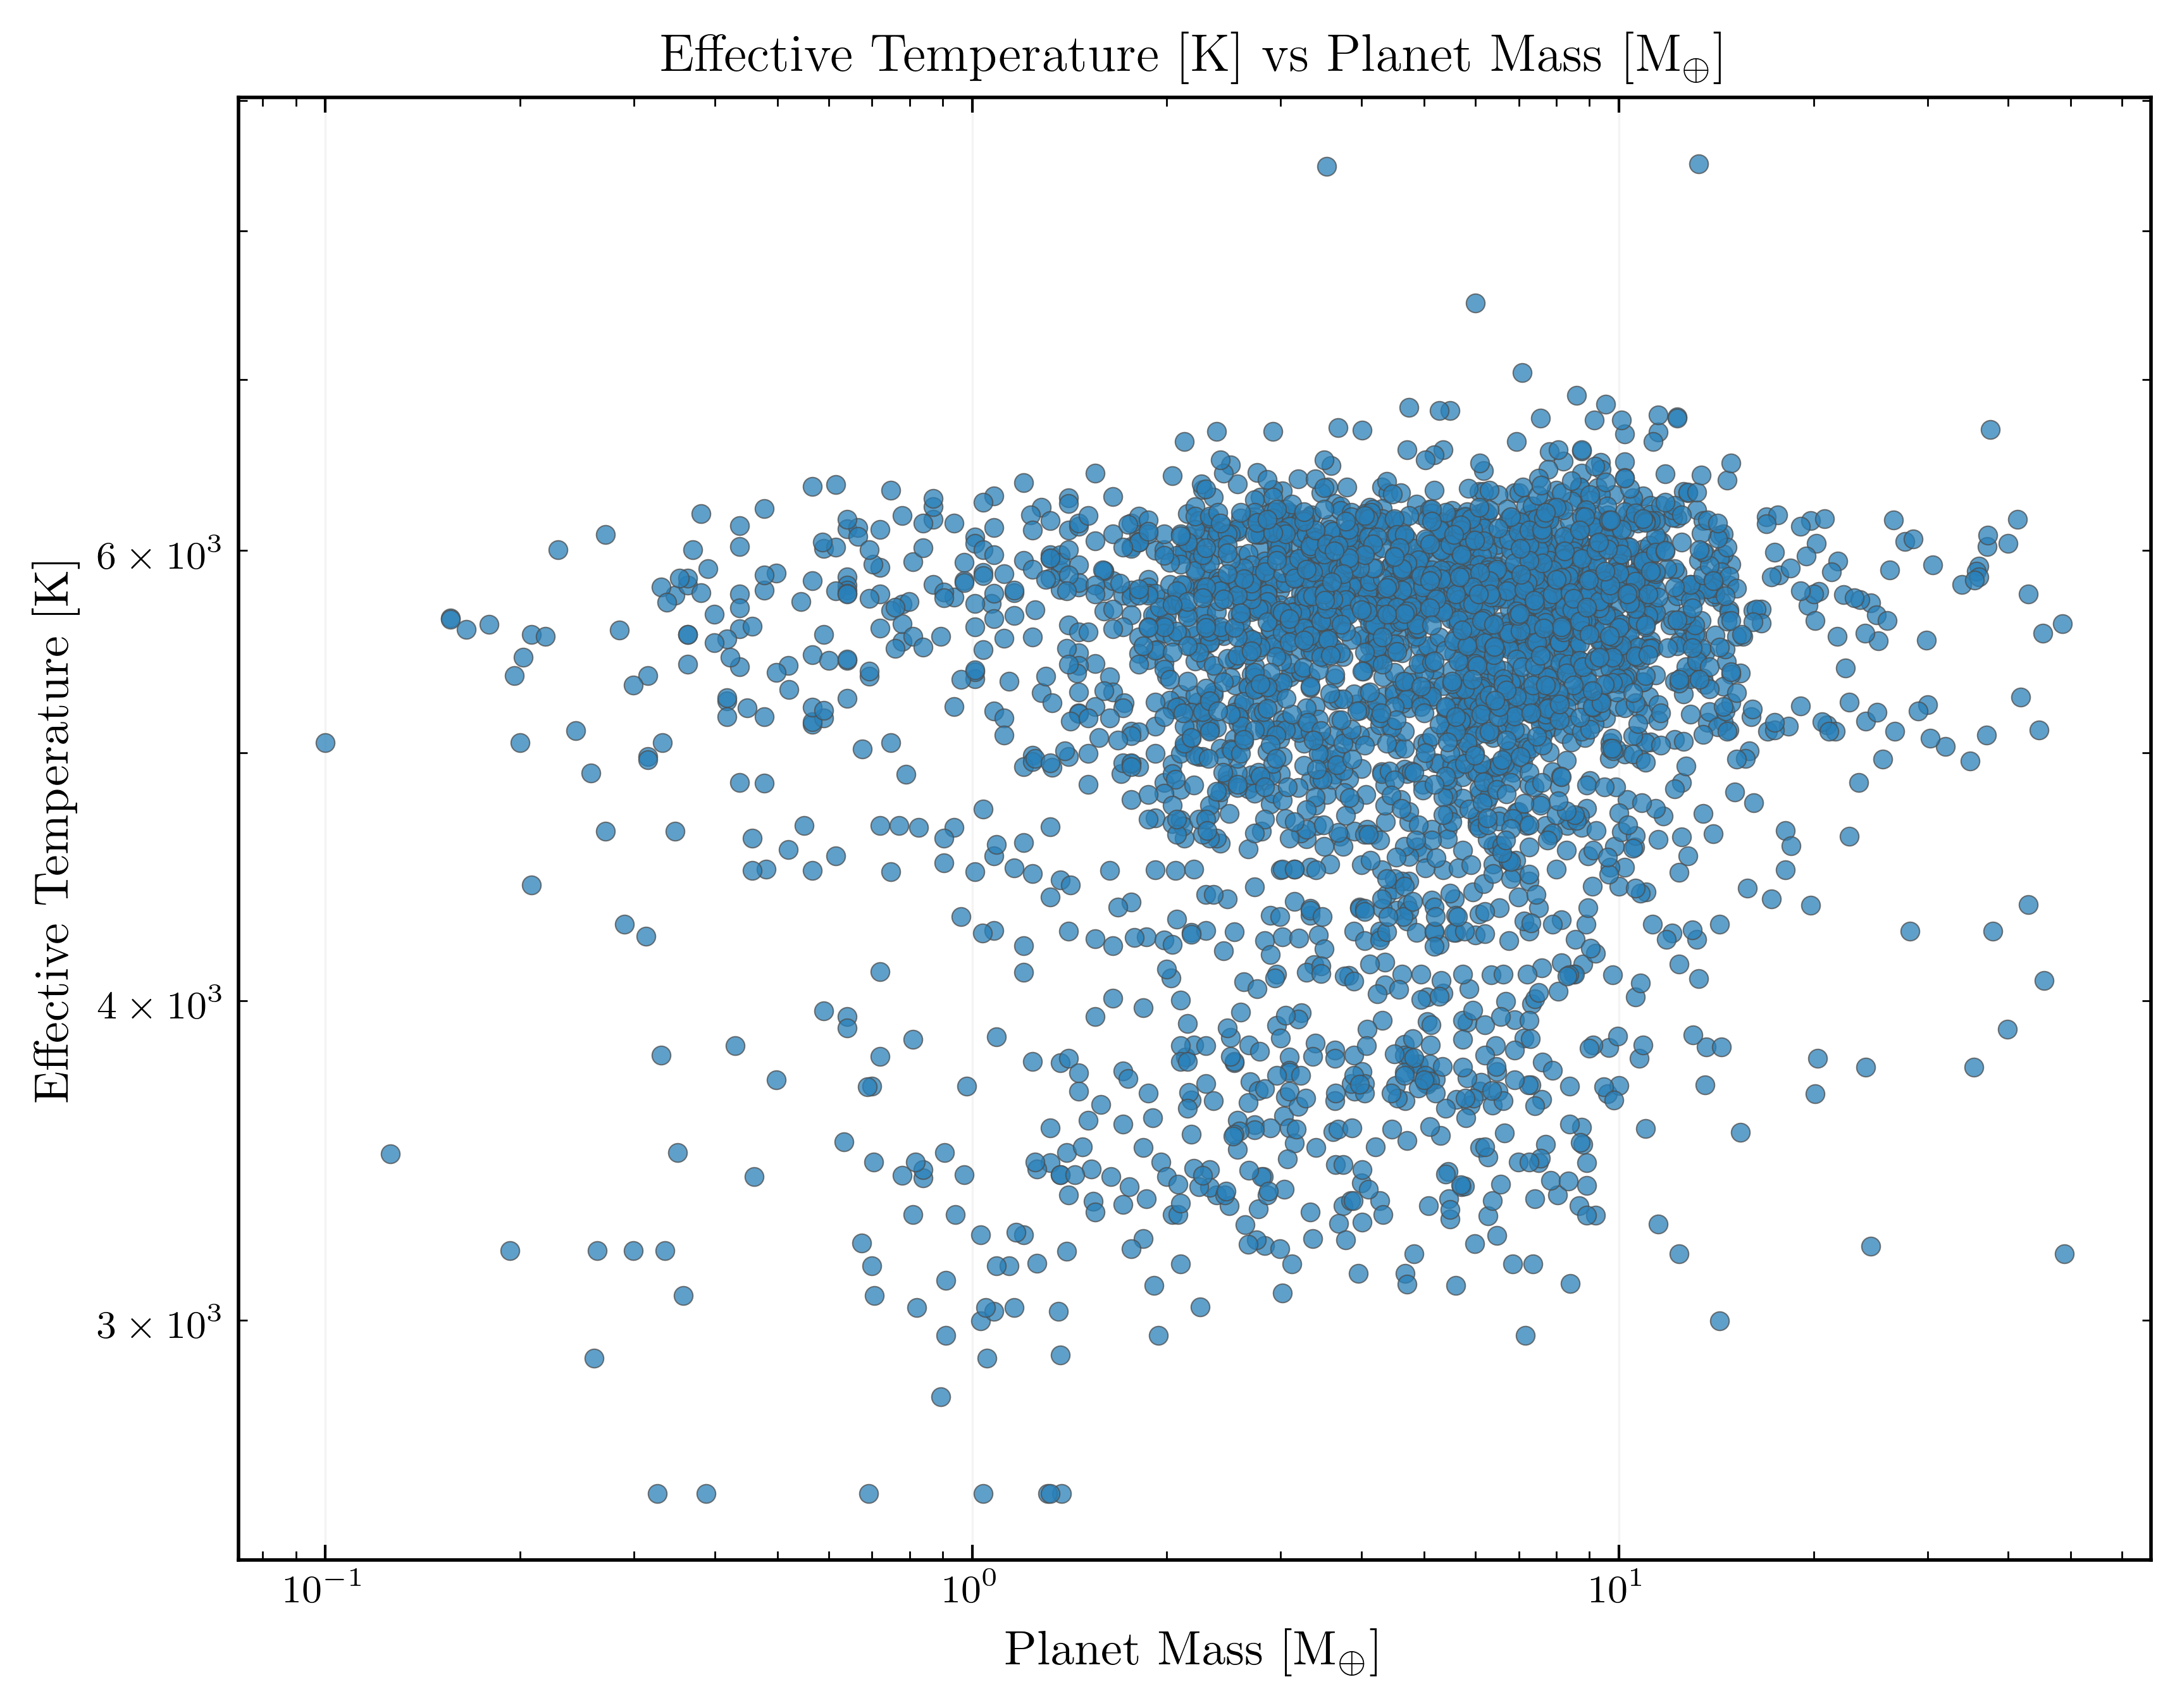


5d. plot_scatter() — color_by, highlights, model overlays
  [PASS] color_by + highlights + 3 models overlaid


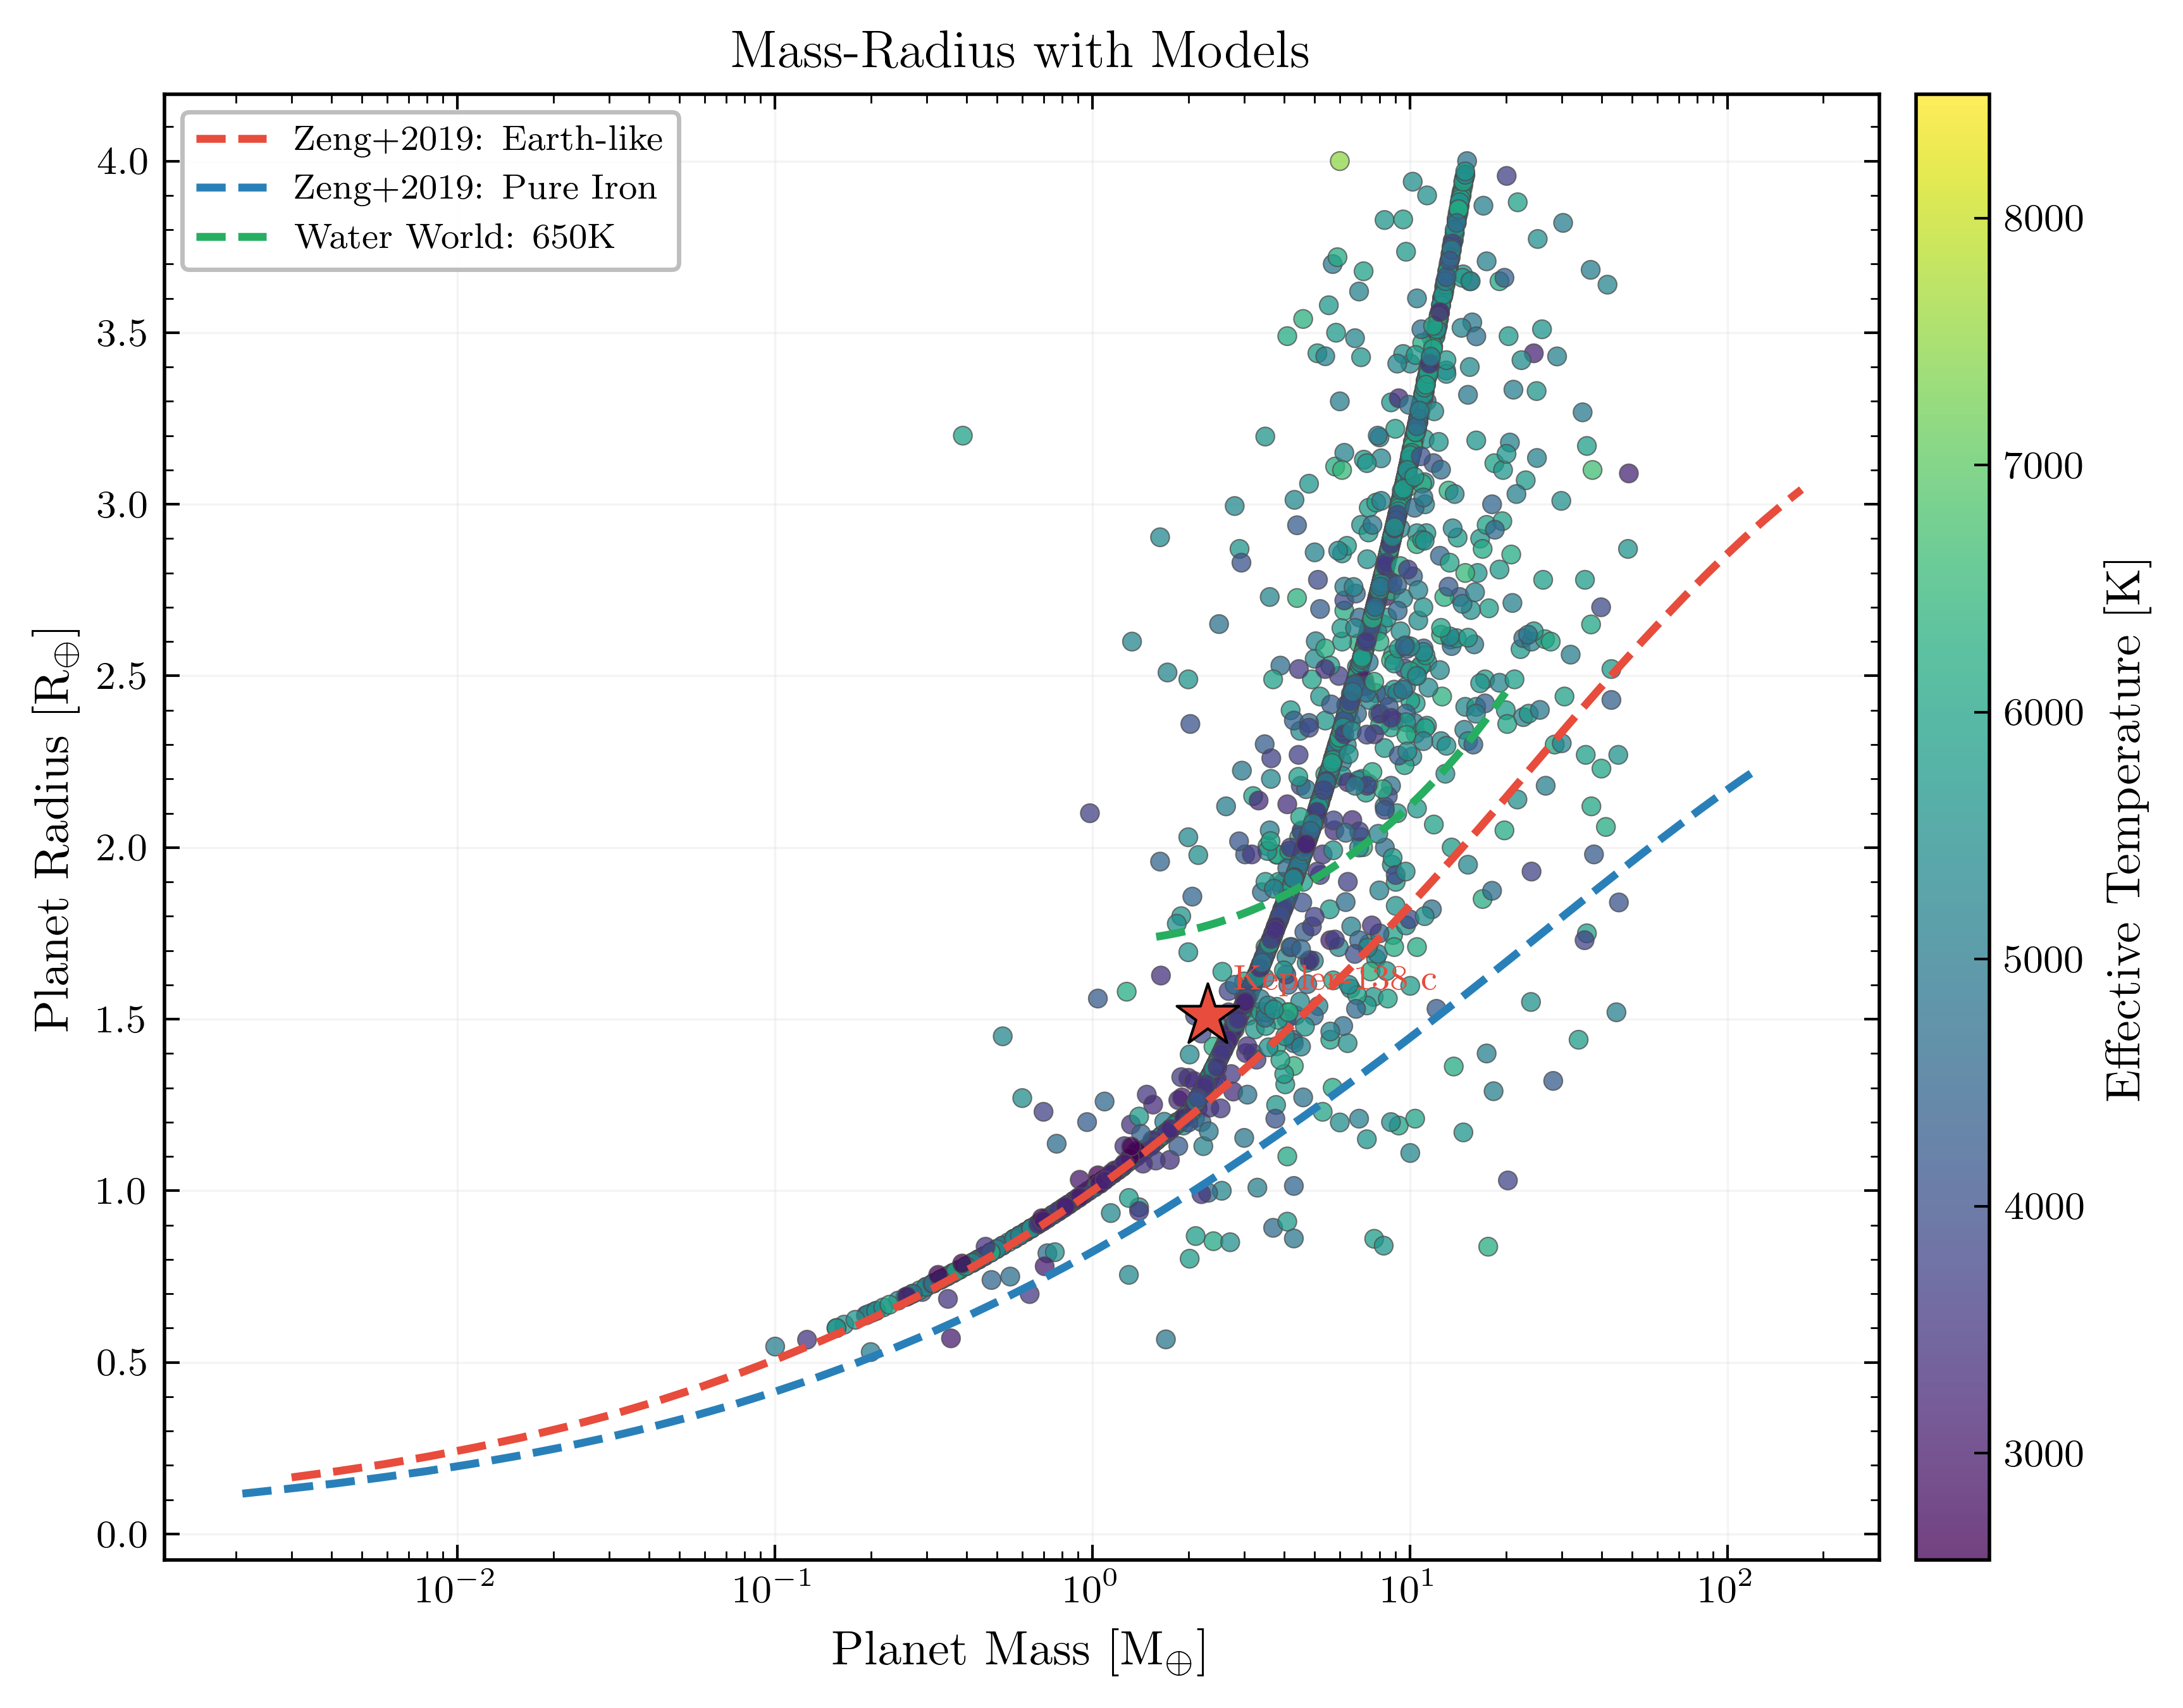


5e. plot_scatter() — custom figsize
  [PASS] Custom figsize: 10 × 4 inches

5f. plot_density()
  [PASS] Density plot with log-x, Gaussian sigma=5


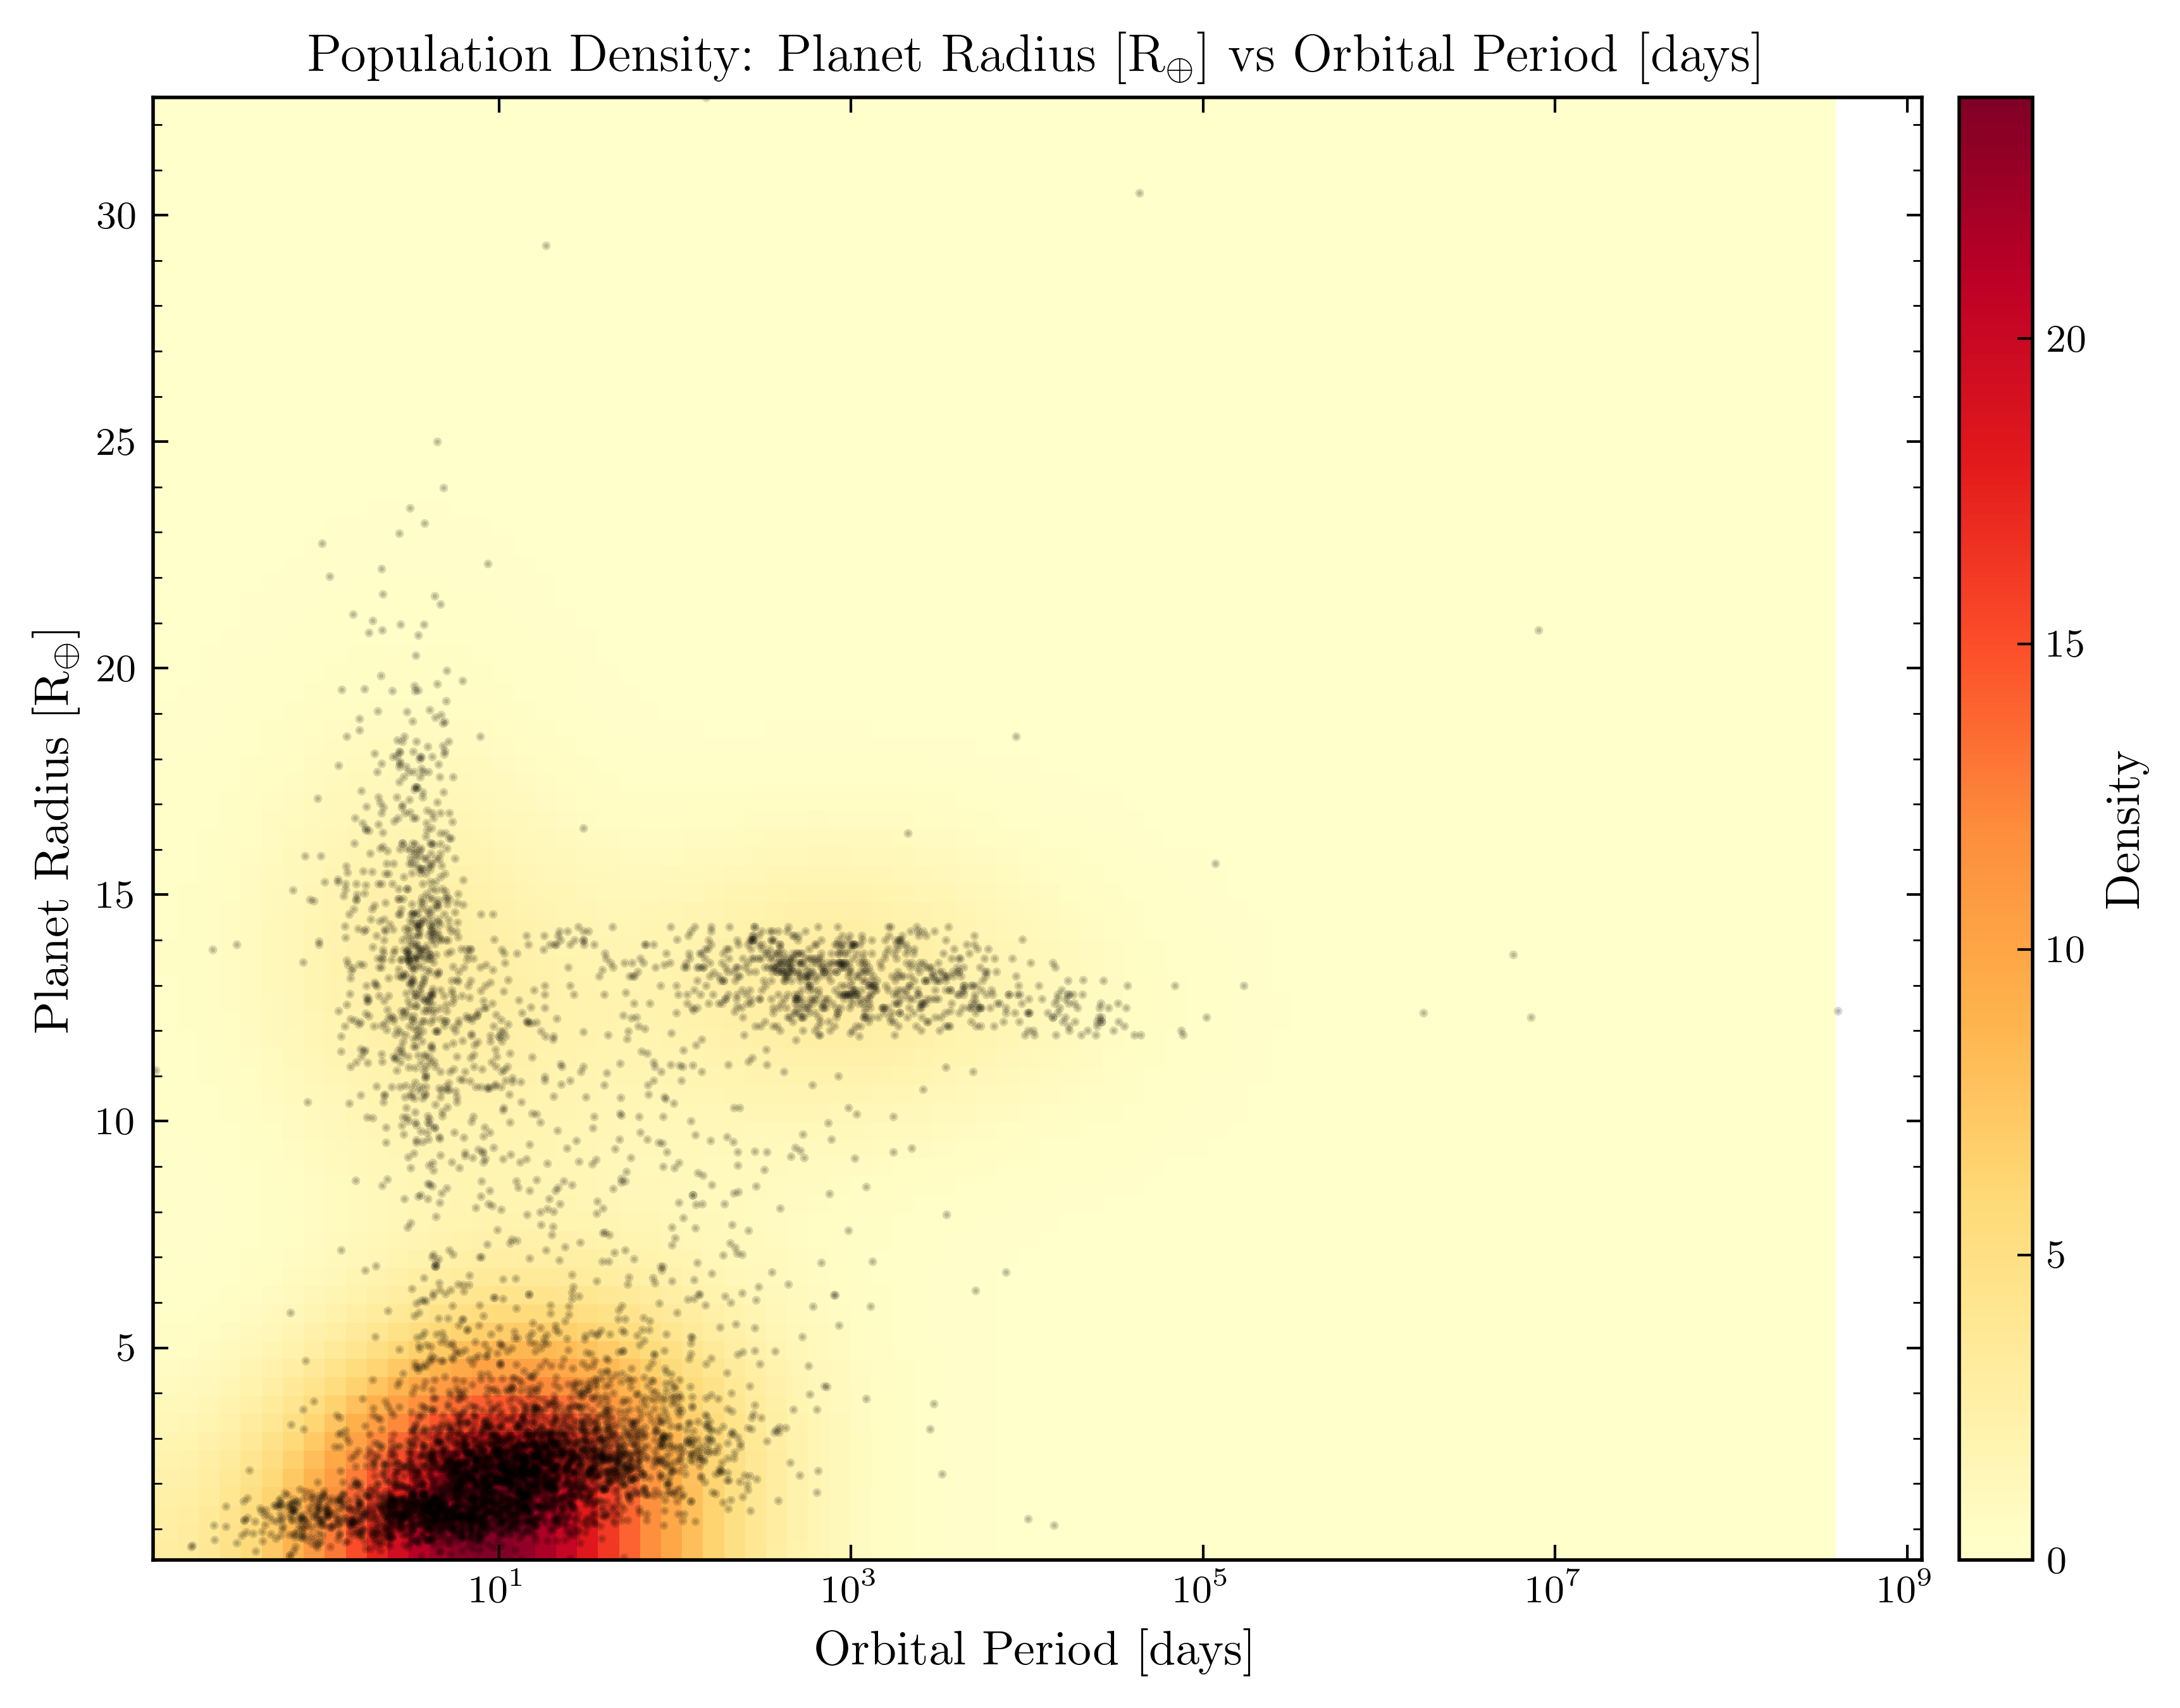

  [PASS] Density plot with show_points=False


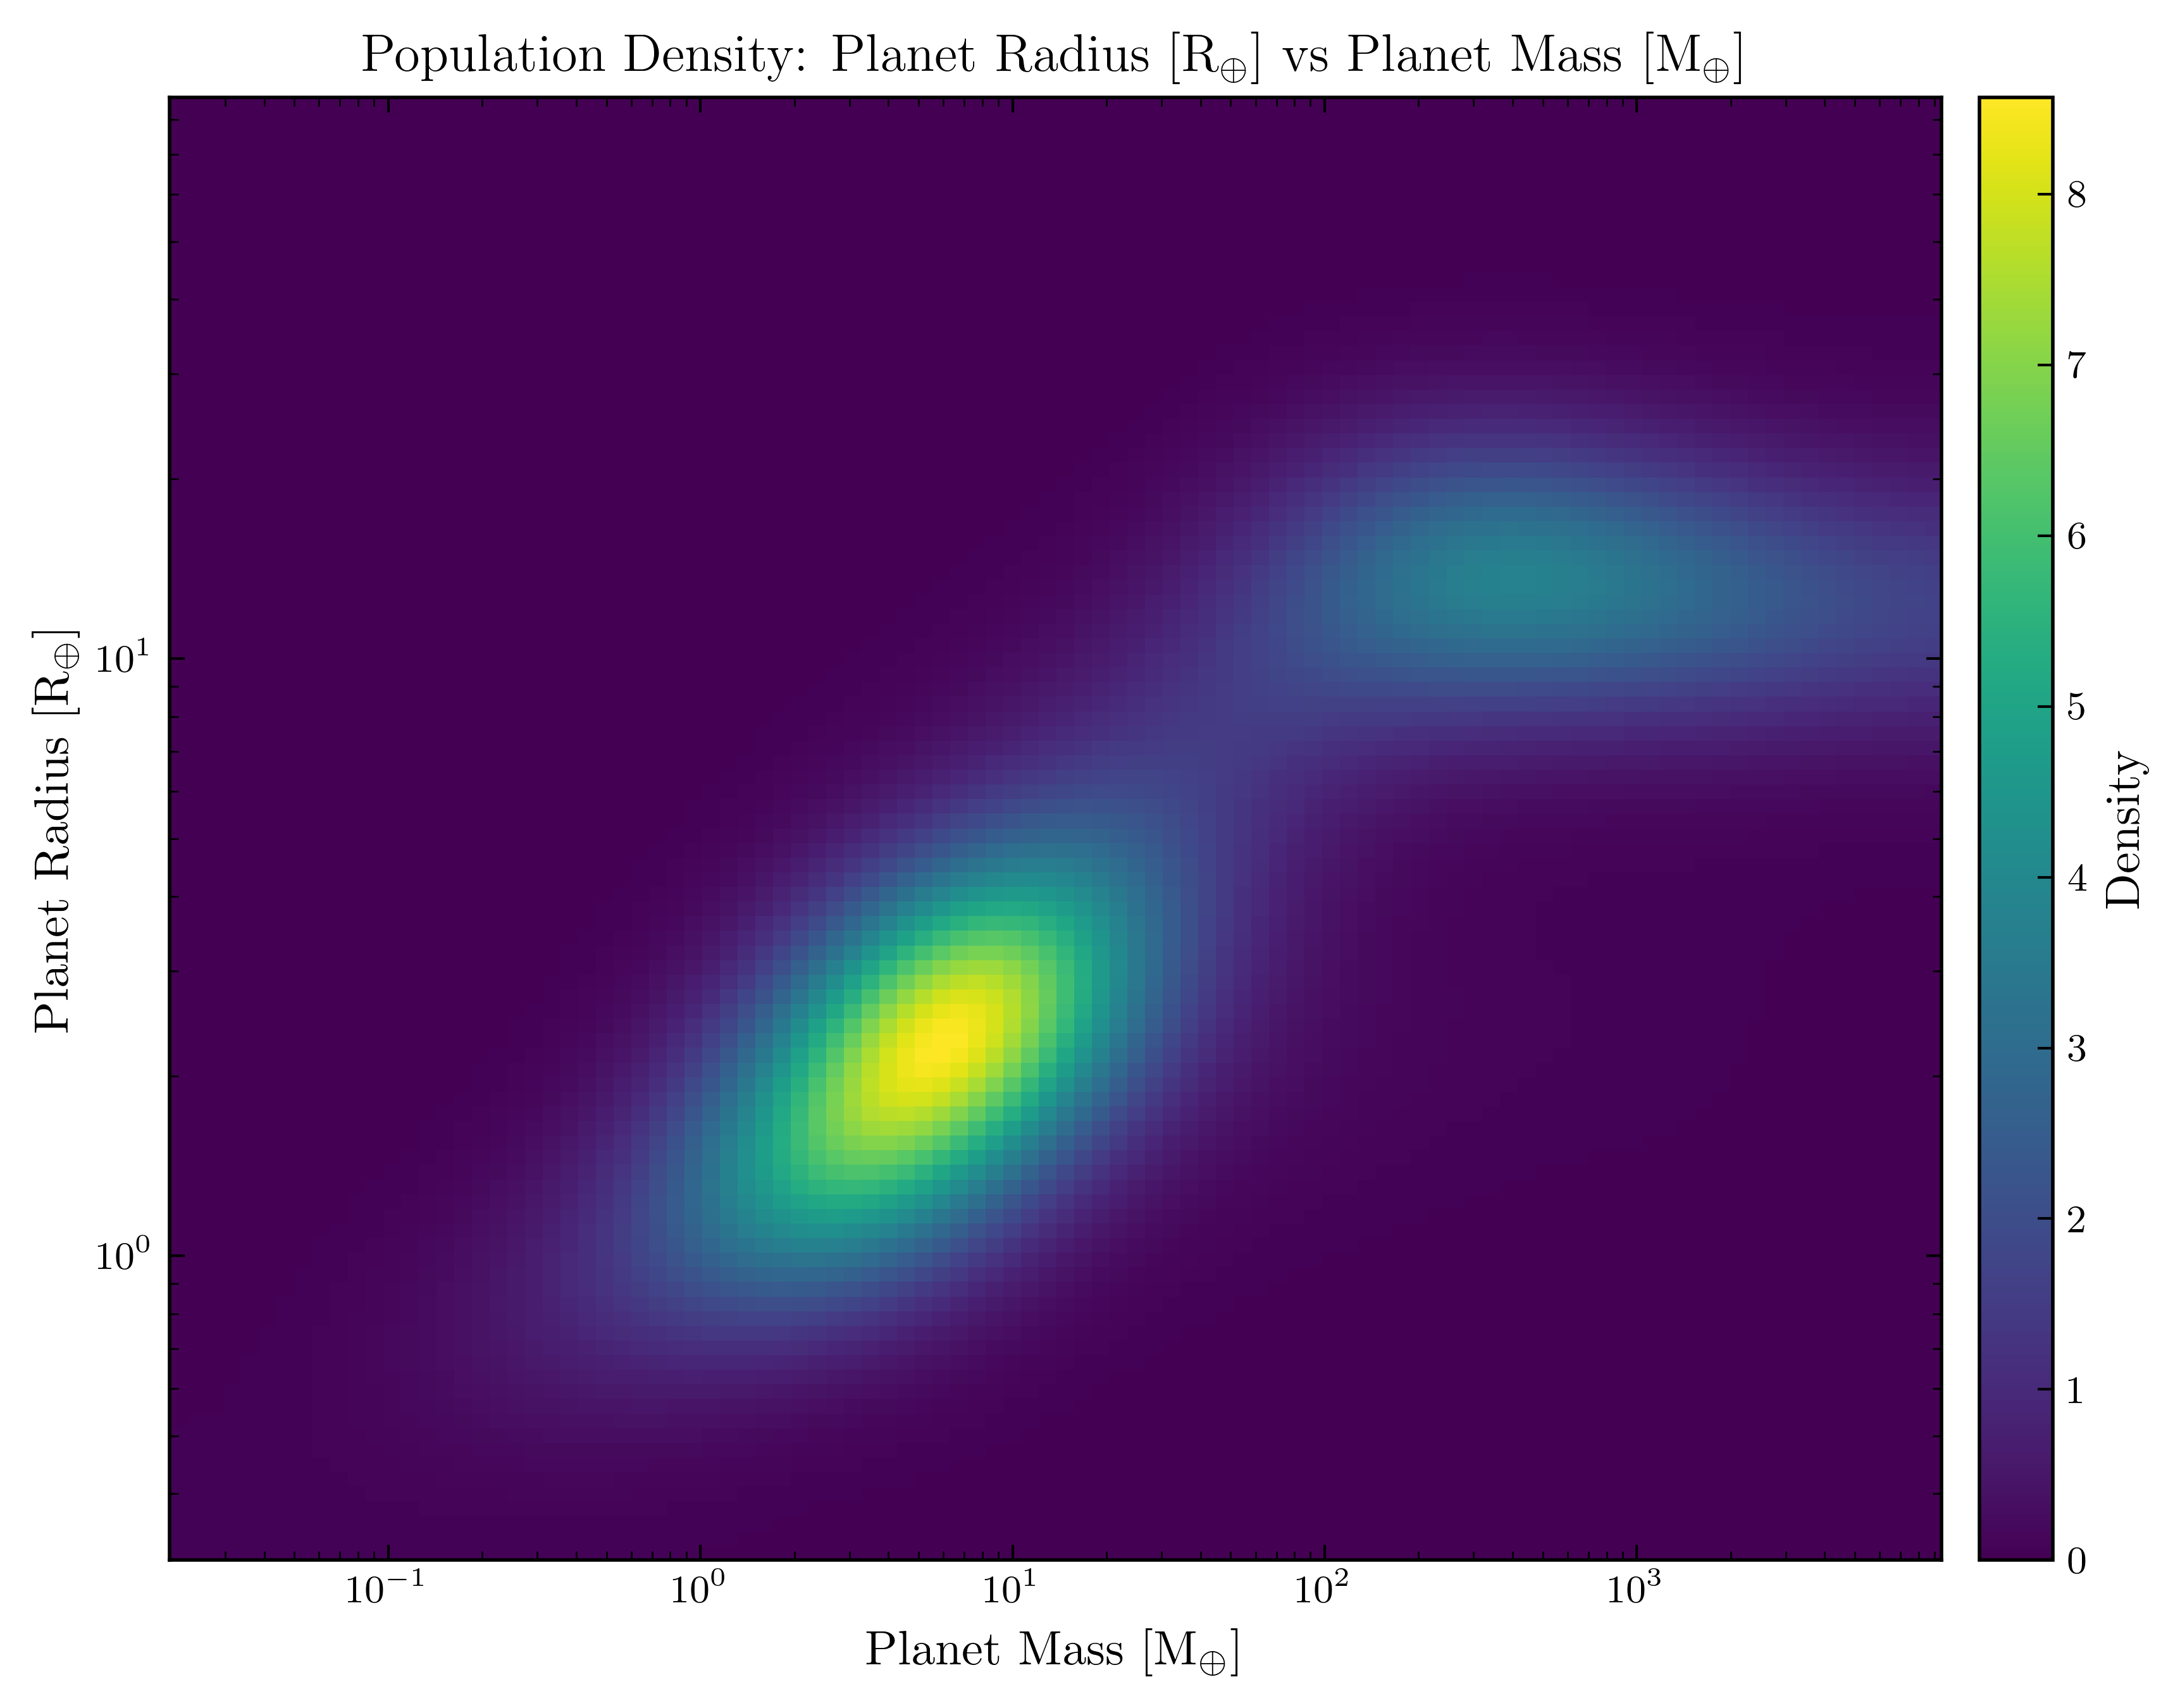


5g. plot_histogram()
  [PASS] Histogram: 40 bins rendered


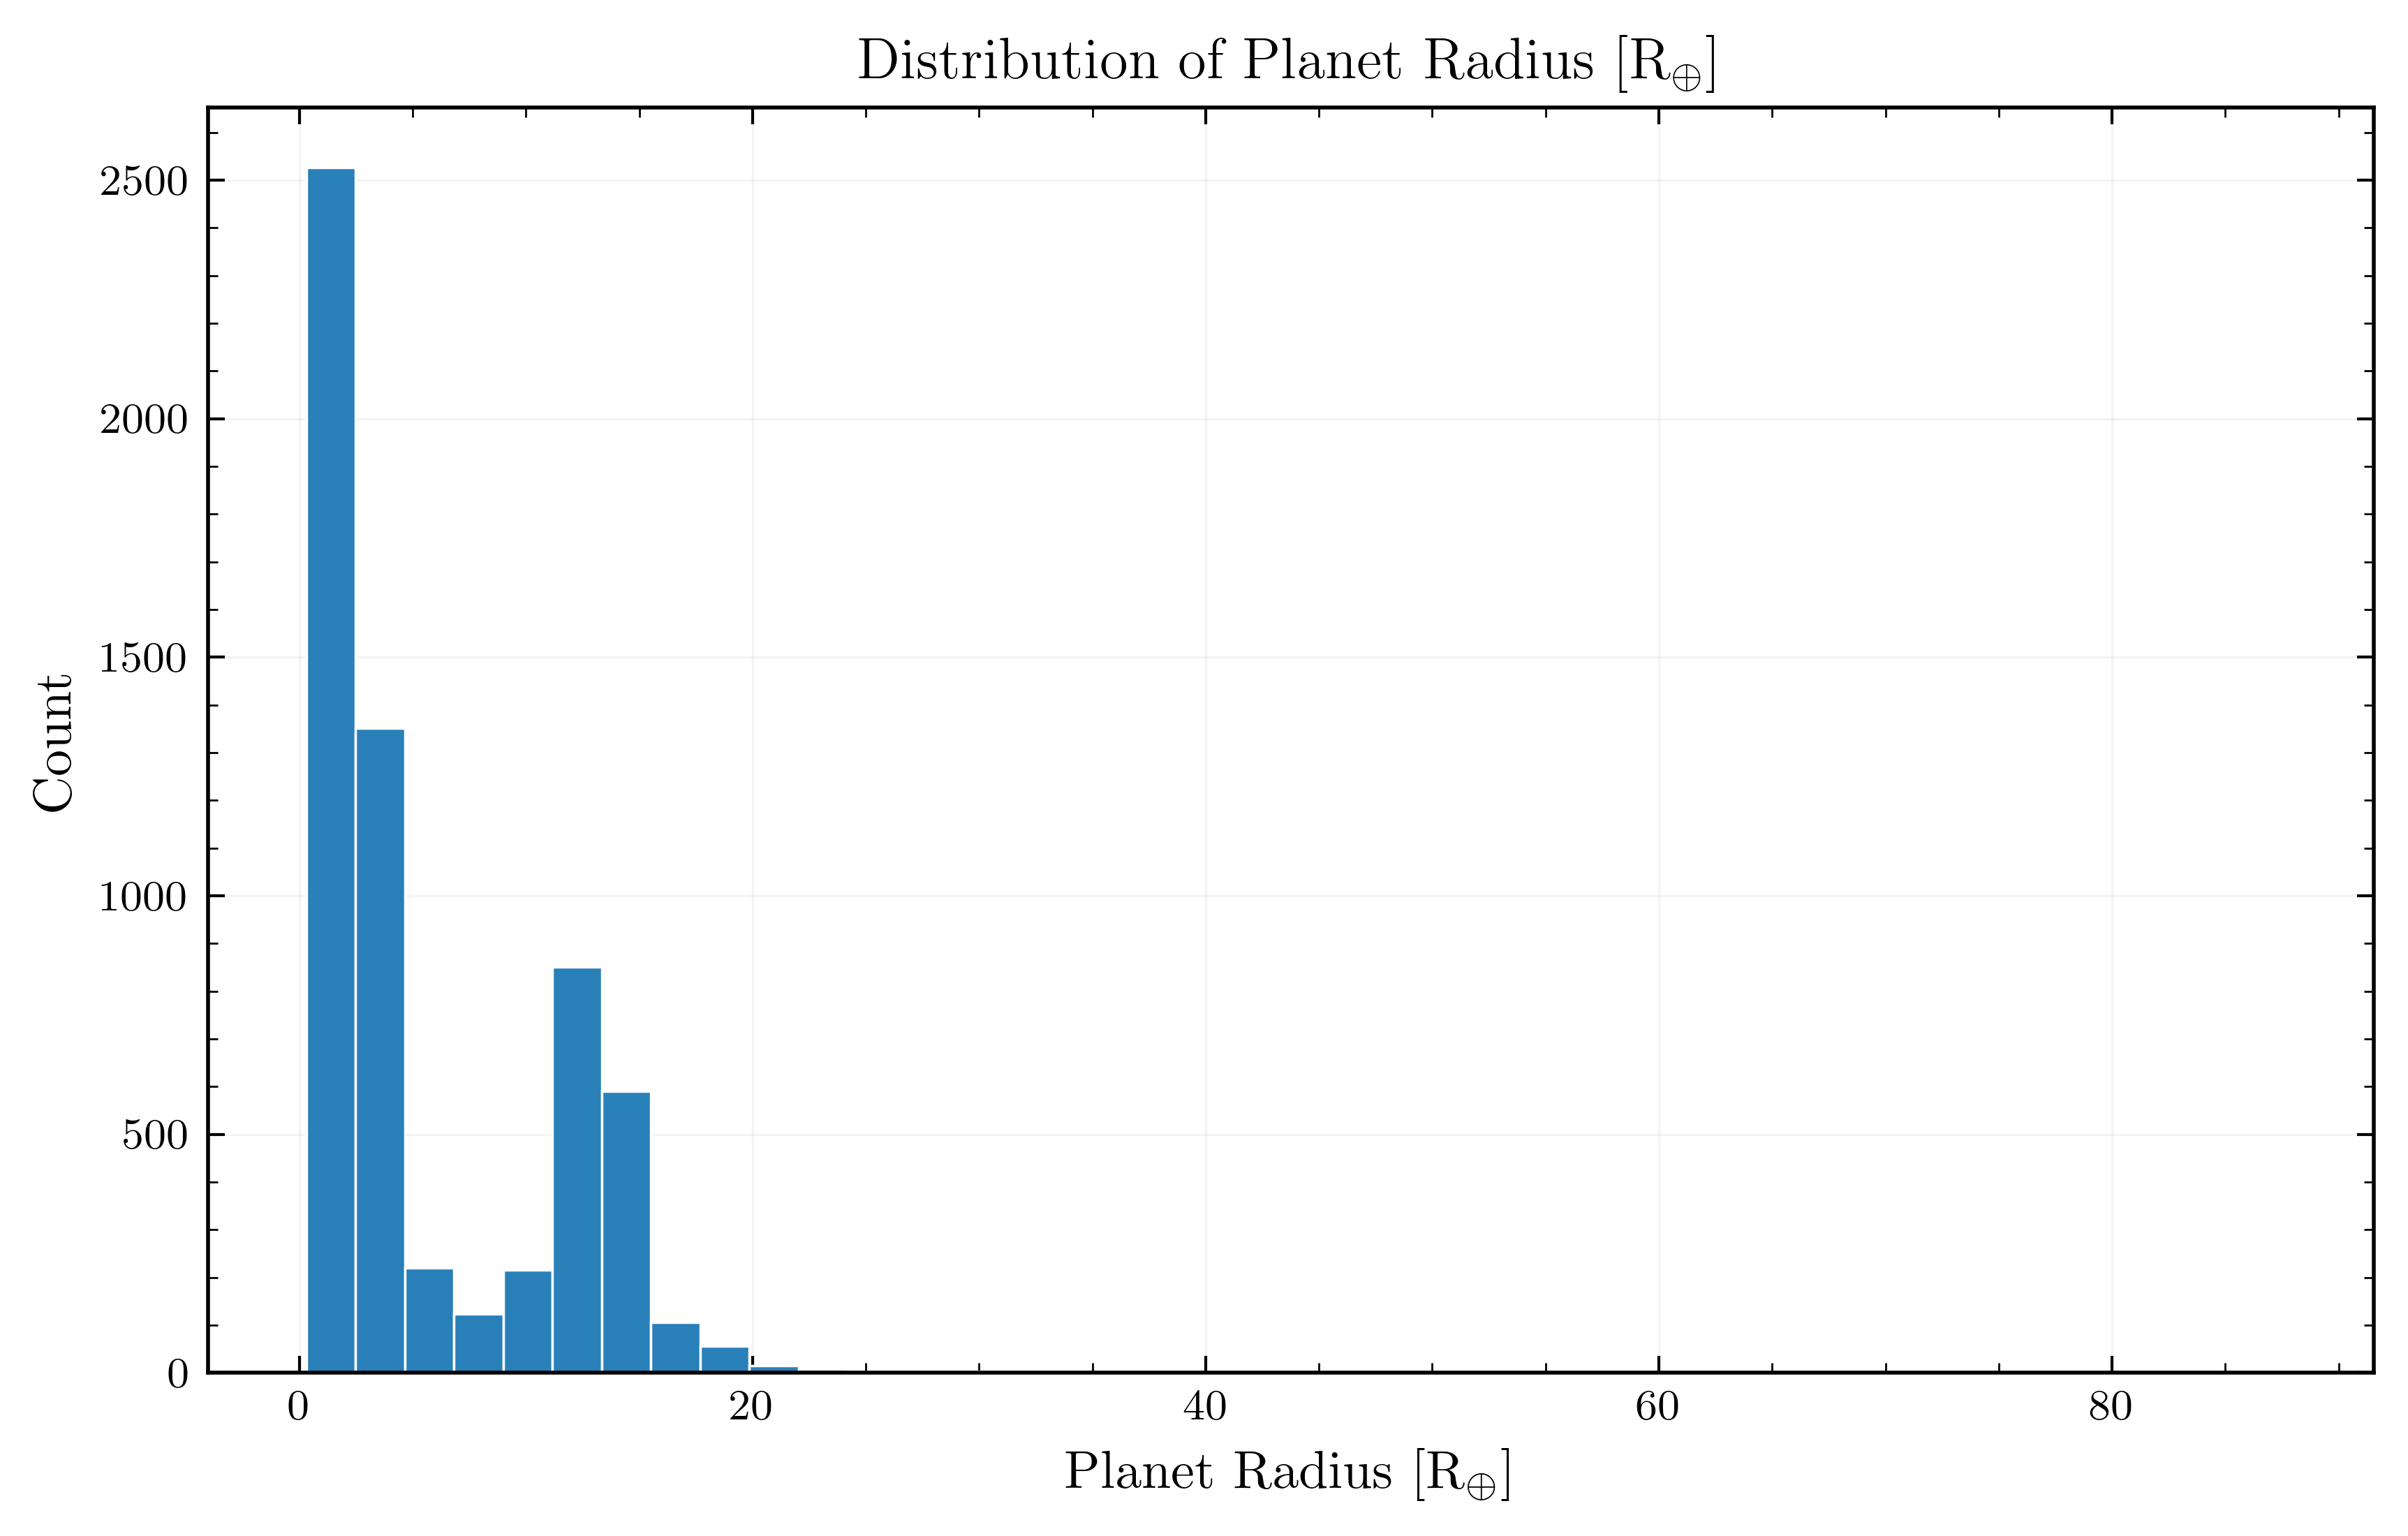

  [PASS] Histogram with log_x + custom color


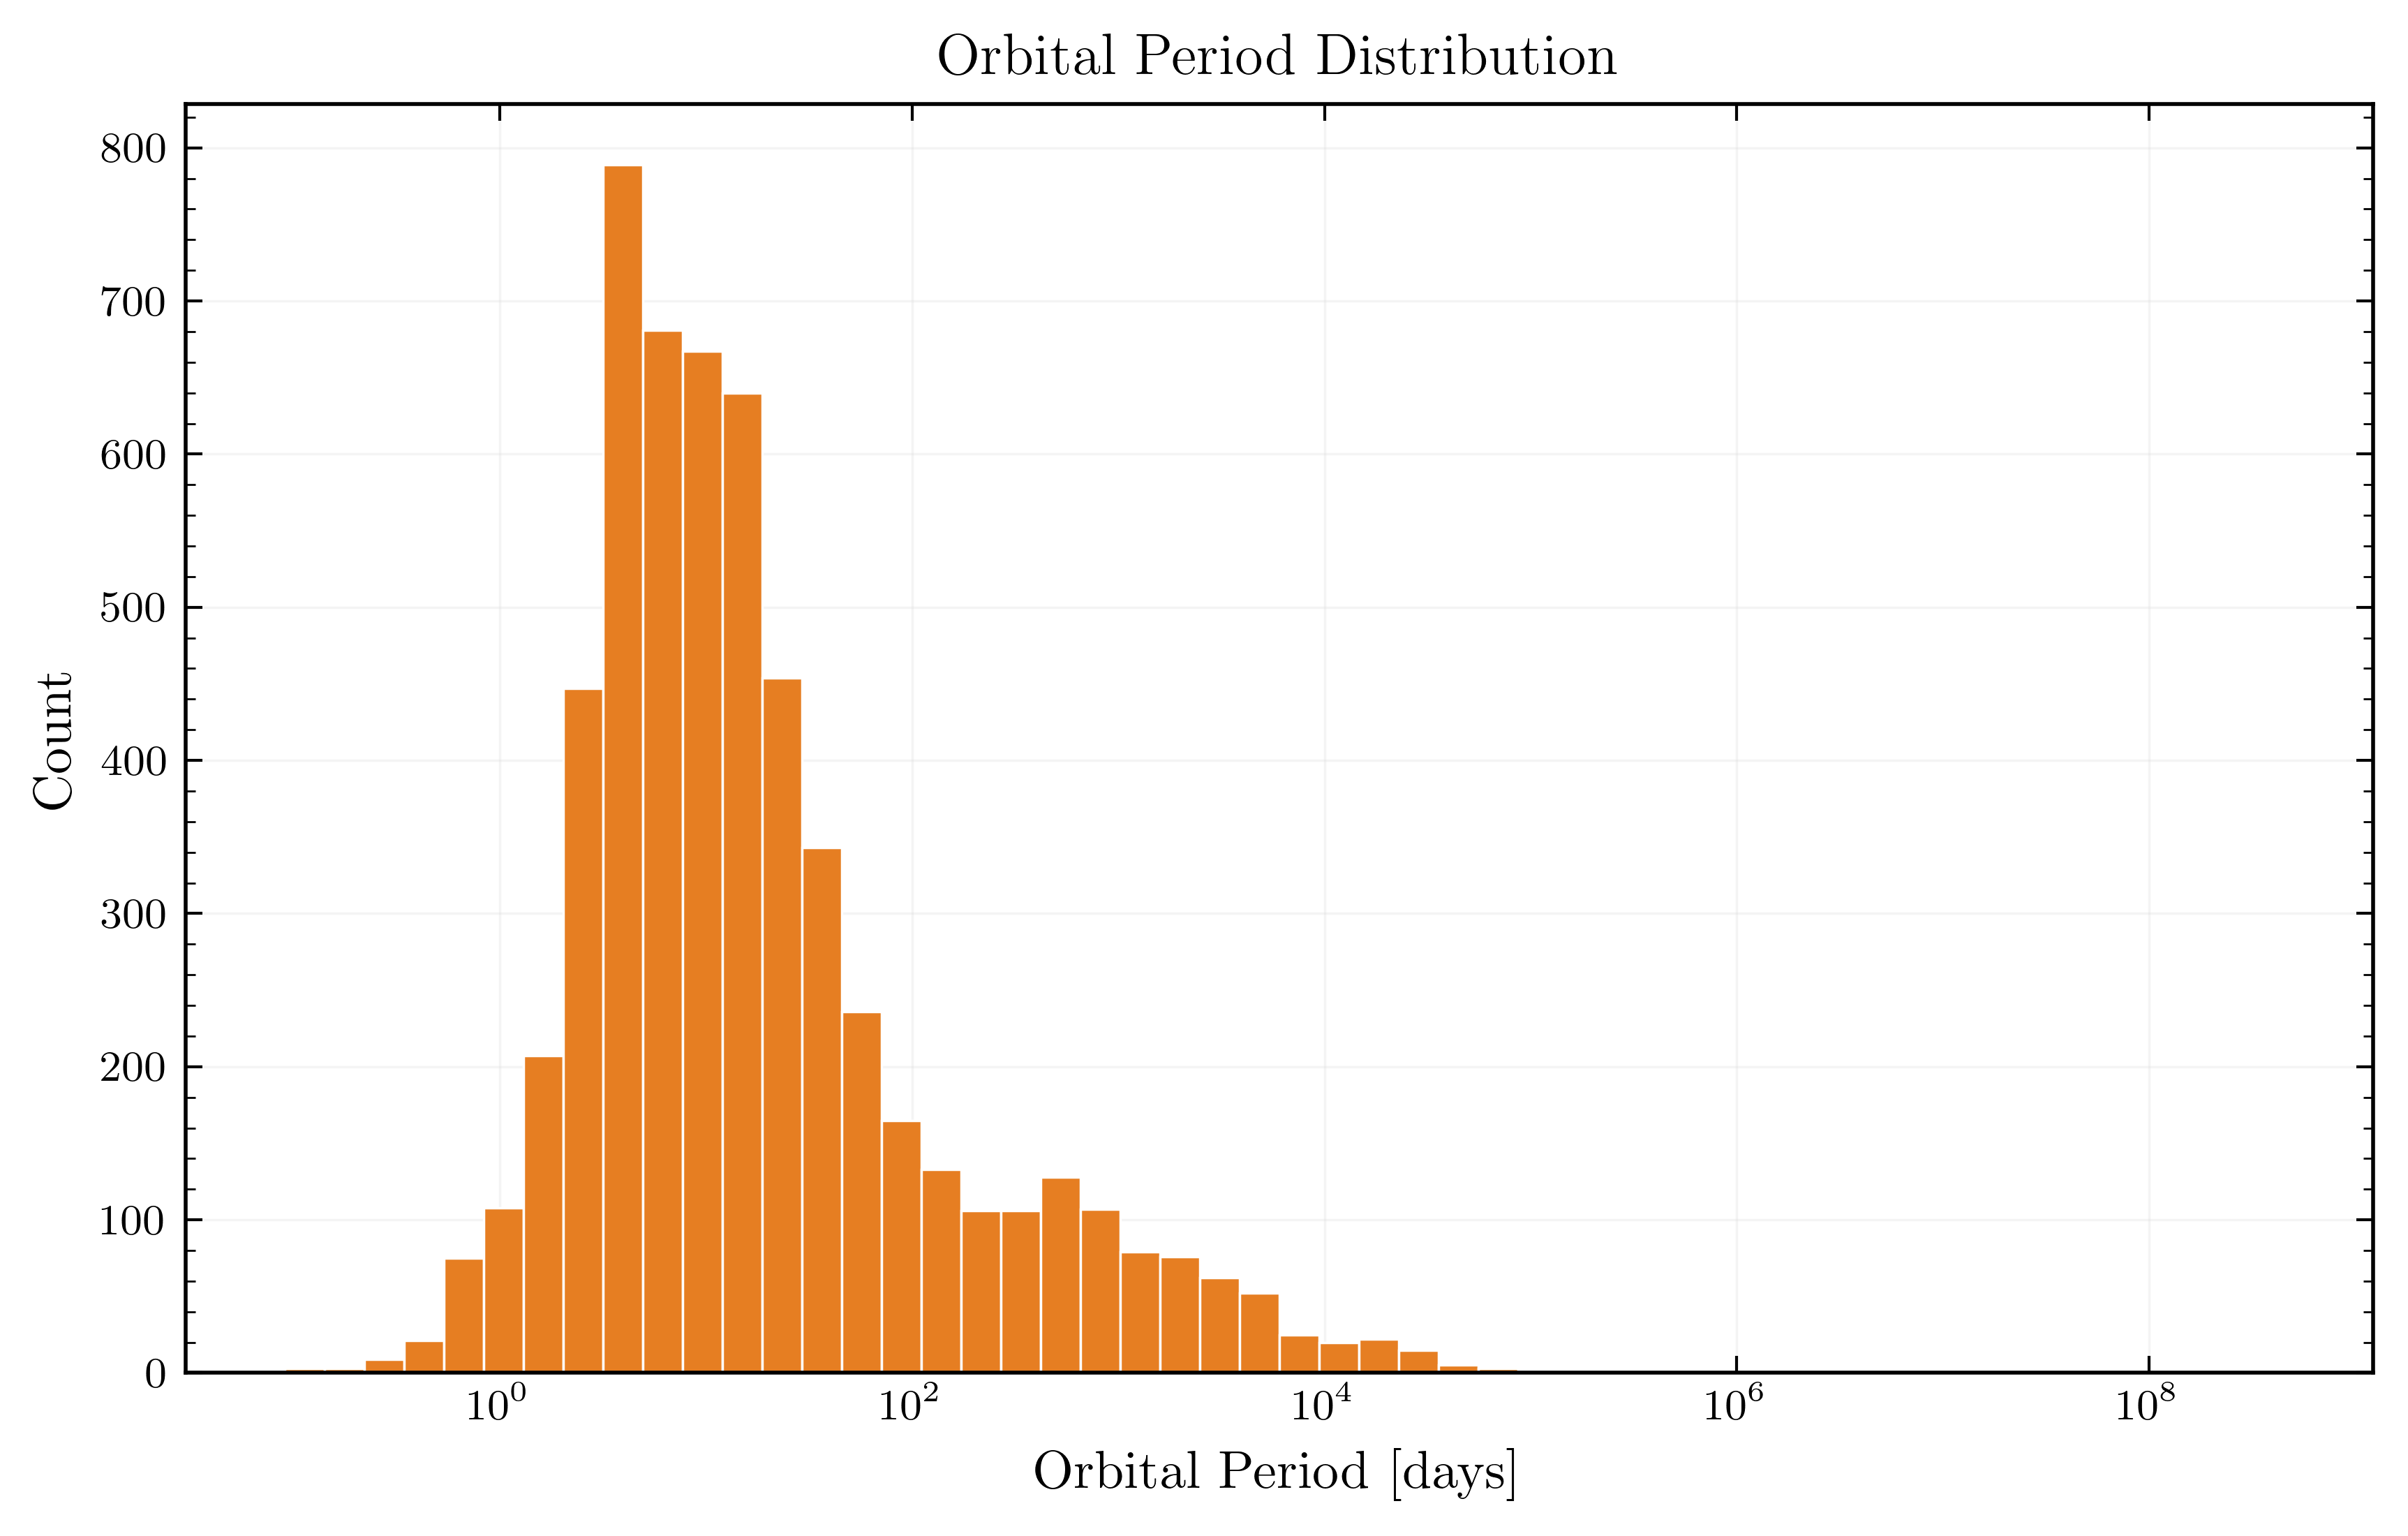

  [PASS] Histogram with log_y

5h. RETURN TYPE CONSISTENCY
  [PASS] plot_scatter returns (Figure, Axes)
  [PASS] plot_density returns (Figure, Axes)
  [PASS] plot_histogram returns (Figure, Axes)

✓ plotting.py (CatalogPlotter) — all checks passed.


In [6]:
ok = lambda msg: print(f"  [PASS] {msg}")

# Prepare a filtered dataset for plotting tests
cat = ExoplanetCatalog(dataset_name='NEA')
full_df = cat.original_df
small_df = cat.filter_planet(rade_min=0.5, rade_max=4, mass_min=0.1, mass_max=50).get_data()
cat.reset()

# ── 5a. PlotStyle ────────────────────────────────────────────────────
print("=" * 60)
print("5a. PlotStyle")
print("=" * 60)

PlotStyle.configure()
assert PlotStyle._configured is True
ok("configure() sets _configured flag")

assert plt.rcParams["text.usetex"] is True
ok("LaTeX enabled by default (usetex=True)")

assert plt.rcParams["figure.dpi"] == 500
assert plt.rcParams["savefig.dpi"] == 500
ok("DPI = 500 (figure + savefig)")

assert "Computer Modern Roman" in plt.rcParams["font.serif"]
ok("Font: Computer Modern Roman")

assert r"\DeclareUnicodeCharacter" in plt.rcParams["text.latex.preamble"]
ok("LaTeX preamble includes Unicode declarations")

label_plain = PlotStyle.get_label('pl_orbeccen')
assert label_plain == "Eccentricity"
ok(f"get_label('pl_orbeccen') → '{label_plain}'")

label_sub = PlotStyle.get_label('pl_rade')
assert "$_{" in label_sub and "}$" in label_sub
ok(f"get_label('pl_rade') HTML→LaTeX → '{label_sub}'")

label_unknown = PlotStyle.get_label('nonexistent_column')
assert label_unknown == 'nonexistent_column'
ok(f"get_label unknown key → passthrough '{label_unknown}'")

fig_tmp, ax_tmp = plt.subplots()
PlotStyle.polish(ax_tmp, grid=True, minor=True)
ok("polish() applies grid and minorticks without error")
plt.close(fig_tmp)

# ── 5b. CatalogPlotter — instance ────────────────────────────────────
print("\n" + "=" * 60)
print("5b. CatalogPlotter — instance")
print("=" * 60)

cp = CatalogPlotter()
assert hasattr(cp, 'model_loader')
assert isinstance(cp.model_loader, MassRadiusModels)
ok(f"model_loader is MassRadiusModels")

r = repr(cp)
assert "CatalogPlotter" in r
ok(f"__repr__ → {r}")

# ── 5c. plot_scatter — basic ─────────────────────────────────────────
print("\n" + "=" * 60)
print("5c. plot_scatter() — basic")
print("=" * 60)

fig, ax = cp.plot_scatter(small_df, 'pl_bmasse', 'st_teff', log_x=True, log_y=True)
assert isinstance(fig, plt.Figure)
assert isinstance(ax, plt.Axes)
assert ax.get_xscale() == 'log'
assert ax.get_yscale() == 'log'
ok(f"Basic scatter: {fig.get_size_inches()}, log-log axes")
plt.show()
plt.close(fig)

# ── 5d. plot_scatter — color_by + highlights + models ─────────────────
print("\n" + "=" * 60)
print("5d. plot_scatter() — color_by, highlights, model overlays")
print("=" * 60)

fig, ax = cp.plot_scatter(
    small_df, 'pl_bmasse', 'pl_rade',
    color_by='st_teff',
    highlight_planets=['Kepler-138 c'],
    log_x=True, log_y=False,
    overlay_models=['zeng_earth', 'zeng_iron', 'Water World'],
    cmap='viridis',
    title="Mass-Radius with Models"
)
assert len(ax.get_lines()) >= 3, "Should have at least 3 model overlay lines"
ok(f"color_by + highlights + 3 models overlaid")
plt.show()
plt.close(fig)

# ── 5e. plot_scatter — custom figsize and title ───────────────────────
print("\n" + "=" * 60)
print("5e. plot_scatter() — custom figsize")
print("=" * 60)

fig, ax = cp.plot_scatter(small_df, 'pl_orbper', 'pl_rade',
                          log_x=True, figsize=(10, 4), title="Custom Size Test")
w, h = fig.get_size_inches()
assert abs(w - 10) < 0.1 and abs(h - 4) < 0.1
ok(f"Custom figsize: {w:.0f} × {h:.0f} inches")
plt.close(fig)

# ── 5f. plot_density ──────────────────────────────────────────────────
print("\n" + "=" * 60)
print("5f. plot_density()")
print("=" * 60)

fig, ax = cp.plot_density(full_df, 'pl_orbper', 'pl_rade',
                          log_x=True, log_y=False, cmap='YlOrRd',
                          sigma=5, bins=80)
assert isinstance(fig, plt.Figure)
ok("Density plot with log-x, Gaussian sigma=5")
plt.show()
plt.close(fig)

fig, ax = cp.plot_density(full_df, 'pl_bmasse', 'pl_rade',
                          log_x=True, log_y=True,
                          show_points=False, cmap='viridis')
ok("Density plot with show_points=False")
plt.show()
plt.close(fig)

# ── 5g. plot_histogram ────────────────────────────────────────────────
print("\n" + "=" * 60)
print("5g. plot_histogram()")
print("=" * 60)

fig, ax = cp.plot_histogram(full_df, 'pl_rade', bins=40)
assert isinstance(fig, plt.Figure)
n_patches = len(ax.patches)
assert n_patches > 0
ok(f"Histogram: {n_patches} bins rendered")
plt.show()
plt.close(fig)

fig, ax = cp.plot_histogram(full_df, 'pl_orbper', bins=50,
                            log_x=True, color='#e67e22',
                            title="Orbital Period Distribution")
assert ax.get_xscale() == 'log'
ok("Histogram with log_x + custom color")
plt.show()
plt.close(fig)

fig, ax = cp.plot_histogram(full_df, 'st_teff', bins=60, log_y=True)
assert ax.get_yscale() == 'log'
ok("Histogram with log_y")
plt.close(fig)

# ── 5h. Return type consistency ───────────────────────────────────────
print("\n" + "=" * 60)
print("5h. RETURN TYPE CONSISTENCY")
print("=" * 60)

for method_name, call in [
    ("plot_scatter", lambda: cp.plot_scatter(small_df, 'pl_bmasse', 'pl_rade')),
    ("plot_density", lambda: cp.plot_density(full_df, 'pl_bmasse', 'pl_rade')),
    ("plot_histogram", lambda: cp.plot_histogram(full_df, 'pl_rade')),
]:
    result = call()
    assert isinstance(result, tuple) and len(result) == 2
    assert isinstance(result[0], plt.Figure)
    ok(f"{method_name} returns (Figure, Axes)")
    plt.close(result[0])

print(f"\n✓ plotting.py (CatalogPlotter) — all checks passed.")

---
### 6. Lightcurve Processing (`lightcurve.py`)
Moving to individual systems, this cell tests the `LightCurveAnalyzer`. It verifies the automated MAST archive query, data downloading and cleaning, Box Least Squares (BLS) periodogram computation, and phase-folding mechanics.

In [7]:
# ==========================================
# 5. Lightcurve Processing (lightcurve.py)
# ==========================================
TARGET = "WASP 76"
analyzer = LightCurveAnalyzer(TARGET)

# Method: search()
search_df = analyzer.search()
print(f"Search Results for {TARGET}:")
display(search_df)

# Method: download_and_clean()
analyzer.download_and_clean(index=0)
print(f"\nRaw Lightcurve Type: {type(analyzer.raw_lc)}")
print(f"Cleaned Lightcurve Type: {type(analyzer.clean_lc)}")

# Method: compute_periodogram()
analyzer.compute_periodogram()
print("\nExtracted BLS Attributes:")
print(f" - best_period: {analyzer.best_period:.6f} days")
print(f" - best_freq: {analyzer.best_freq:.6f} 1/days")
print(f" - best_power: {analyzer.best_power:.2f}")
print(f" - epoch_time: {analyzer.epoch_time:.6f} BJD")

# Method: fold_lightcurve()
analyzer.fold_lightcurve(harmonic=1)
print(f"Folded Lightcurve generated: {analyzer.folded_lc is not None}")

# Method: get_mcmc_data()
time, flux, err, period, t0 = analyzer.get_mcmc_data(folded=True)
print(f"MCMC Data Extracted - Time array shape: {time.shape}")

Search Results for WASP 76:


,mission,year,author,exptime,target_name,distance
0,TESS Sector 30,2020,SPOC,120.0,293435336,0.0
1,TESS Sector 42,2021,SPOC,120.0,293435336,0.0
2,TESS Sector 43,2021,SPOC,120.0,293435336,0.0
3,TESS Sector 97,2025,SPOC,20.0,293435336,0.0
4,TESS Sector 97,2025,SPOC,120.0,293435336,0.0
5,TESS Sector 30,2020,TESS-SPOC,600.0,293435336,0.0
6,TESS Sector 42,2021,TESS-SPOC,600.0,293435336,0.0
7,TESS Sector 43,2021,TESS-SPOC,600.0,293435336,0.0
8,TESS Sector 30,2020,QLP,600.0,293435336,0.0
9,TESS Sector 42,2021,QLP,600.0,293435336,0.0



Raw Lightcurve Type: <class 'lightkurve.lightcurve.TessLightCurve'>
Cleaned Lightcurve Type: <class 'lightkurve.lightcurve.TessLightCurve'>

Extracted BLS Attributes:
 - best_period: 1.812384 days
 - best_freq: 0.551759 1/days
 - best_power: 206057.81
 - epoch_time: 2137.599663 BJD
Folded Lightcurve generated: True
MCMC Data Extracted - Time array shape: (16085,)


---
### 7. MCMC Bayesian Inference (`mcmc.py`)
This cell tests the powerhouse of the backend: `TransitFitter`. It demonstrates the dynamic nature of the code by fitting **5 parameters** (including eccentricity) instead of the default 4. It tests the L-BFGS-B pre-optimization and the `emcee` parallel processing utilizing all CPU cores.

In [ ]:
# ==========================================
# 6. SCIENTIFIC RAW MCMC
# ==========================================
# Notes on the design choices below
# ---------------------------------
# * `t0` is a *fitted* parameter.  BLS picks the deepest cadence-bin
#   centre, which is routinely a few minutes off the true mid-transit;
#   freezing `t0` at that value would leak the offset into Rp/Rs, a/Rs,
#   inc, u1, u2 via the LD ↔ time-shift degeneracy (the WASP-121 b
#   failure mode).  Always include `t0`.
# * `custom_bounds=None` and `custom_x0=None` -> the data-driven
#   `_estimate_bounds` machinery in `TransitFitter` builds bounds and
#   x0 from the geometry of the actual transit (Seager & Mallen-Ornelas
#   inversion).  For a target you have not personally vetted, this is
#   far safer than hand-tuned numbers tuned for some other planet.
# * `ld_prior` can be passed to recentre the soft Gaussian LD prior on
#   Claret coefficients for the actual host star.  Defaults work well
#   for any F/G/K dwarf observed by TESS.

time, flux, err, period_guess, t0_guess = analyzer.get_mcmc_data(folded=False)

# 1. Fitted parameters — note the *required* `t0`.
custom_params = ["rp", "inc", "a", "t0", "per", "u1", "u2"]
custom_labels = [r"$R_p/R_s$", r"$i$ (deg)", r"$a/R_s$",
                 r"$t_0$ (BTJD)", r"$P$ (days)", r"$u_1$", r"$u_2$"]

# 2. Bounds and x0: leave them to the auto-estimator (see `Notes`
#    above).  If you want to override for a specific target you trust,
#    pass `custom_bounds=[...]` and/or `custom_x0=[...]` of the same
#    length and order as `custom_params`.
fitter = TransitFitter(
    time=time, flux=flux, flux_err=err,
    period=period_guess, t0=t0_guess,
    fitted_params=custom_params,
    custom_labels=custom_labels,
    custom_bounds=None,
    custom_x0=None,
    auto_bounds=True,
    # Optional: pass a per-host LD prior centred on Claret coefficients
    # for the actual stellar Teff/logg/[Fe/H], e.g. an F-dwarf:
    # ld_prior={"u1": (0.30, 0.20), "u2": (0.26, 0.15)},
)

# 3. Run optimisation (likelihood-only; user x0 is polished first)
print("Pre-optimizing...")
fitter.optimize_initial_guess()

# 4. The MCMC run
N_WALKERS, N_STEPS = 64, 10000
pbar = tqdm(total=N_STEPS, desc="MCMC Sampling")
last_step = [0]
def update_pbar(current, total):
    pbar.update(current - last_step[0])
    last_step[0] = current

results = fitter.run_mcmc(
    nwalkers=N_WALKERS, nsteps=N_STEPS,
    progress_callback=update_pbar, use_multiprocessing=True,
)
pbar.close()

print("\nIf the results below show non-zero uncertainties, your 'blobs' are back!")
for param, (median, upper, lower) in results.items():
    print(f" {param}: {median:.5f} (+{upper:.5f} / -{lower:.5f})")


---
### 8. Transit Plotting (`plotting.py` — `TransitPlotter`)

Exhaustive validation of `TransitPlotter` static methods:
- `plot_lightcurve()` — scatter / line / errorbar styles, binning, model overlay
- `plot_periodogram()` — period and frequency axis types
- `plot_mcmc_traces()` — trace per parameter, custom figsize
- `plot_mcmc_corner()` — corner plot with quantile lines, custom color
- All return `(fig, axes)` tuples with correct types

8a. TransitPlotter.plot_periodogram()
  [PASS] Periodogram (period mode, log-x)


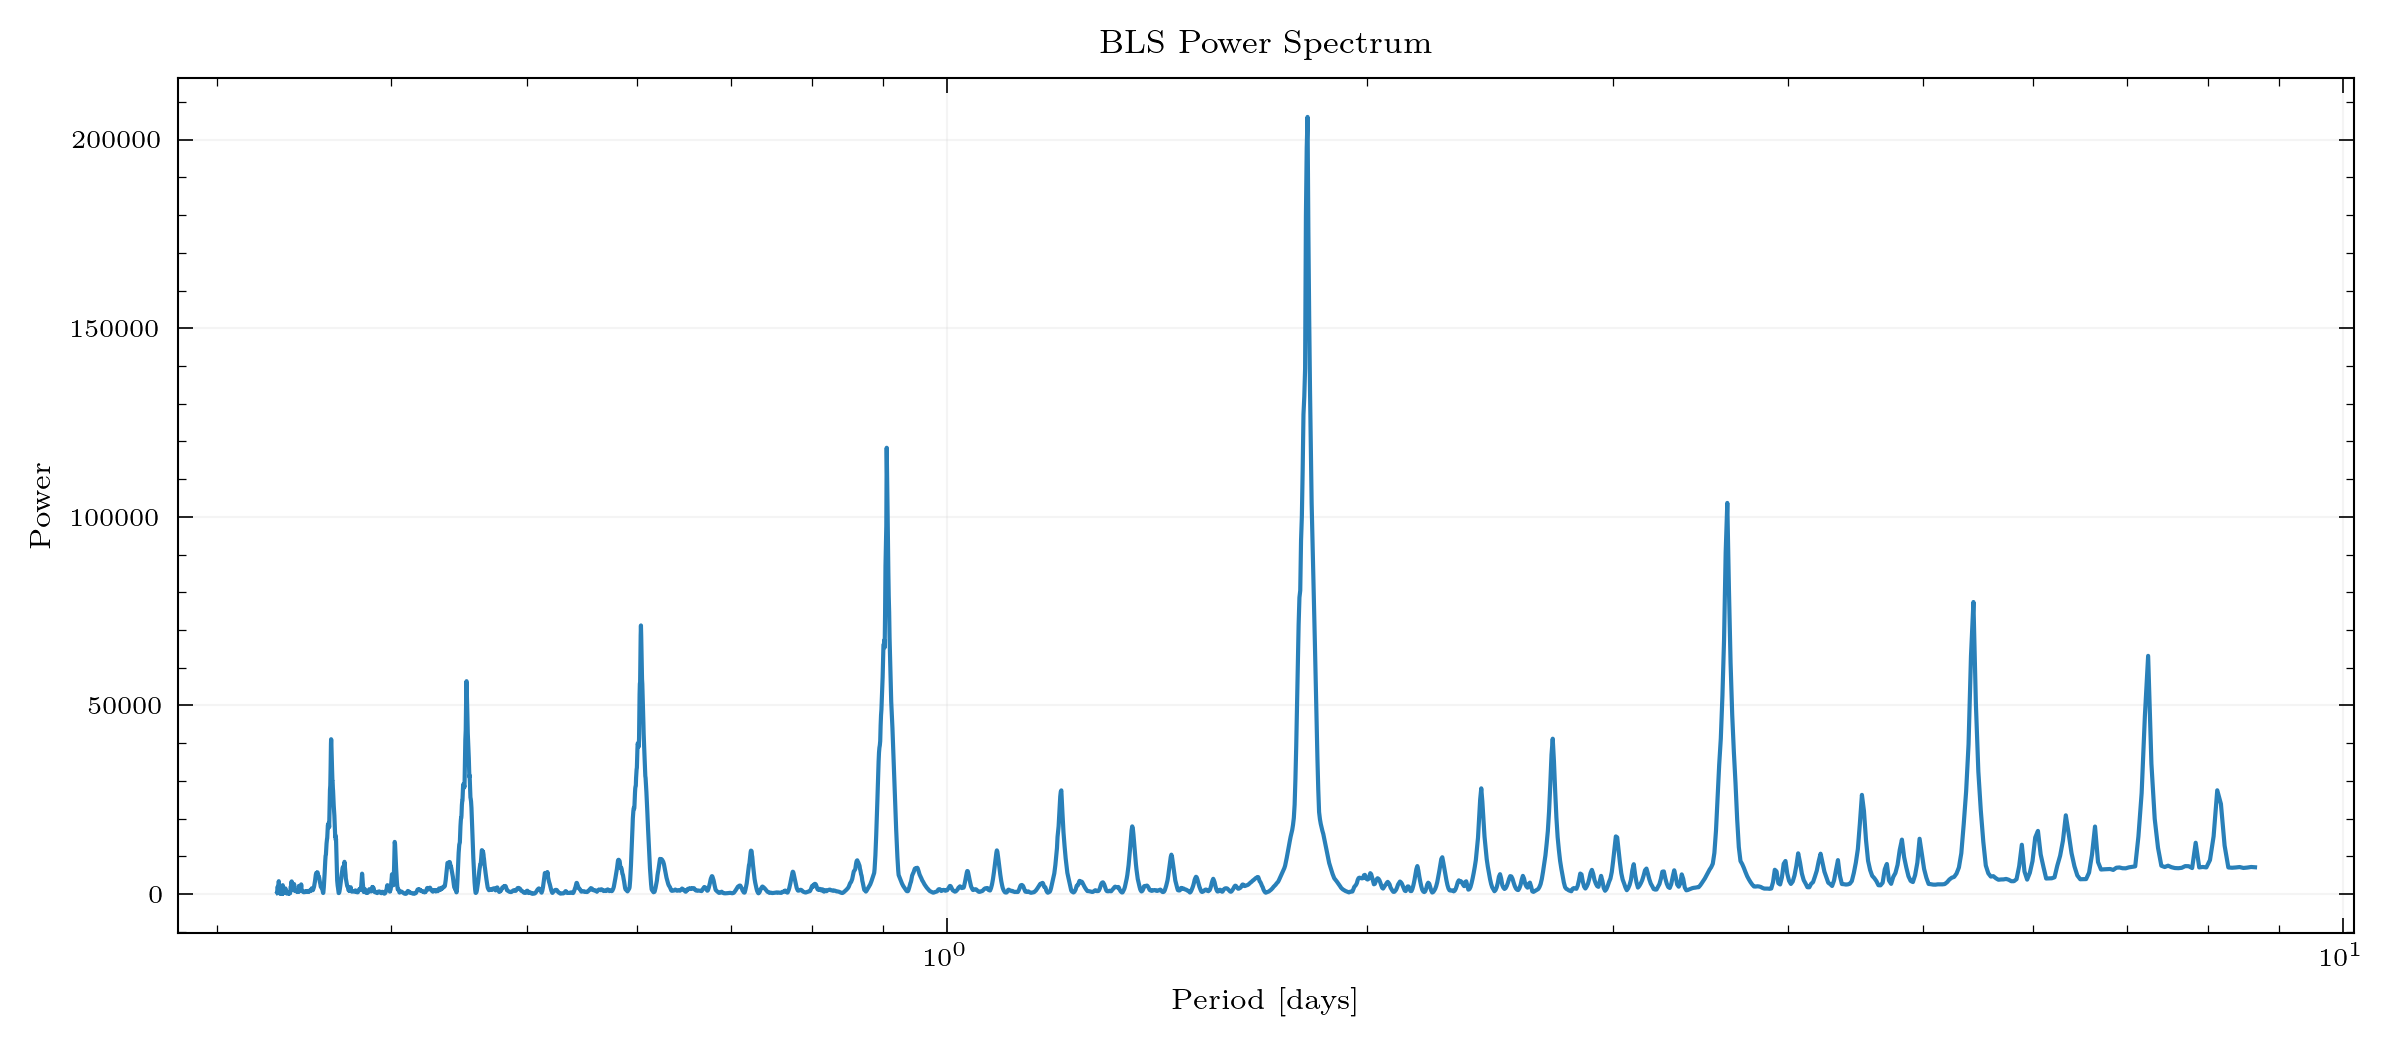

  [PASS] Periodogram (frequency mode, linear-x)

8b. TransitPlotter.plot_lightcurve()
  [PASS] Lightcurve: scatter + model + binning


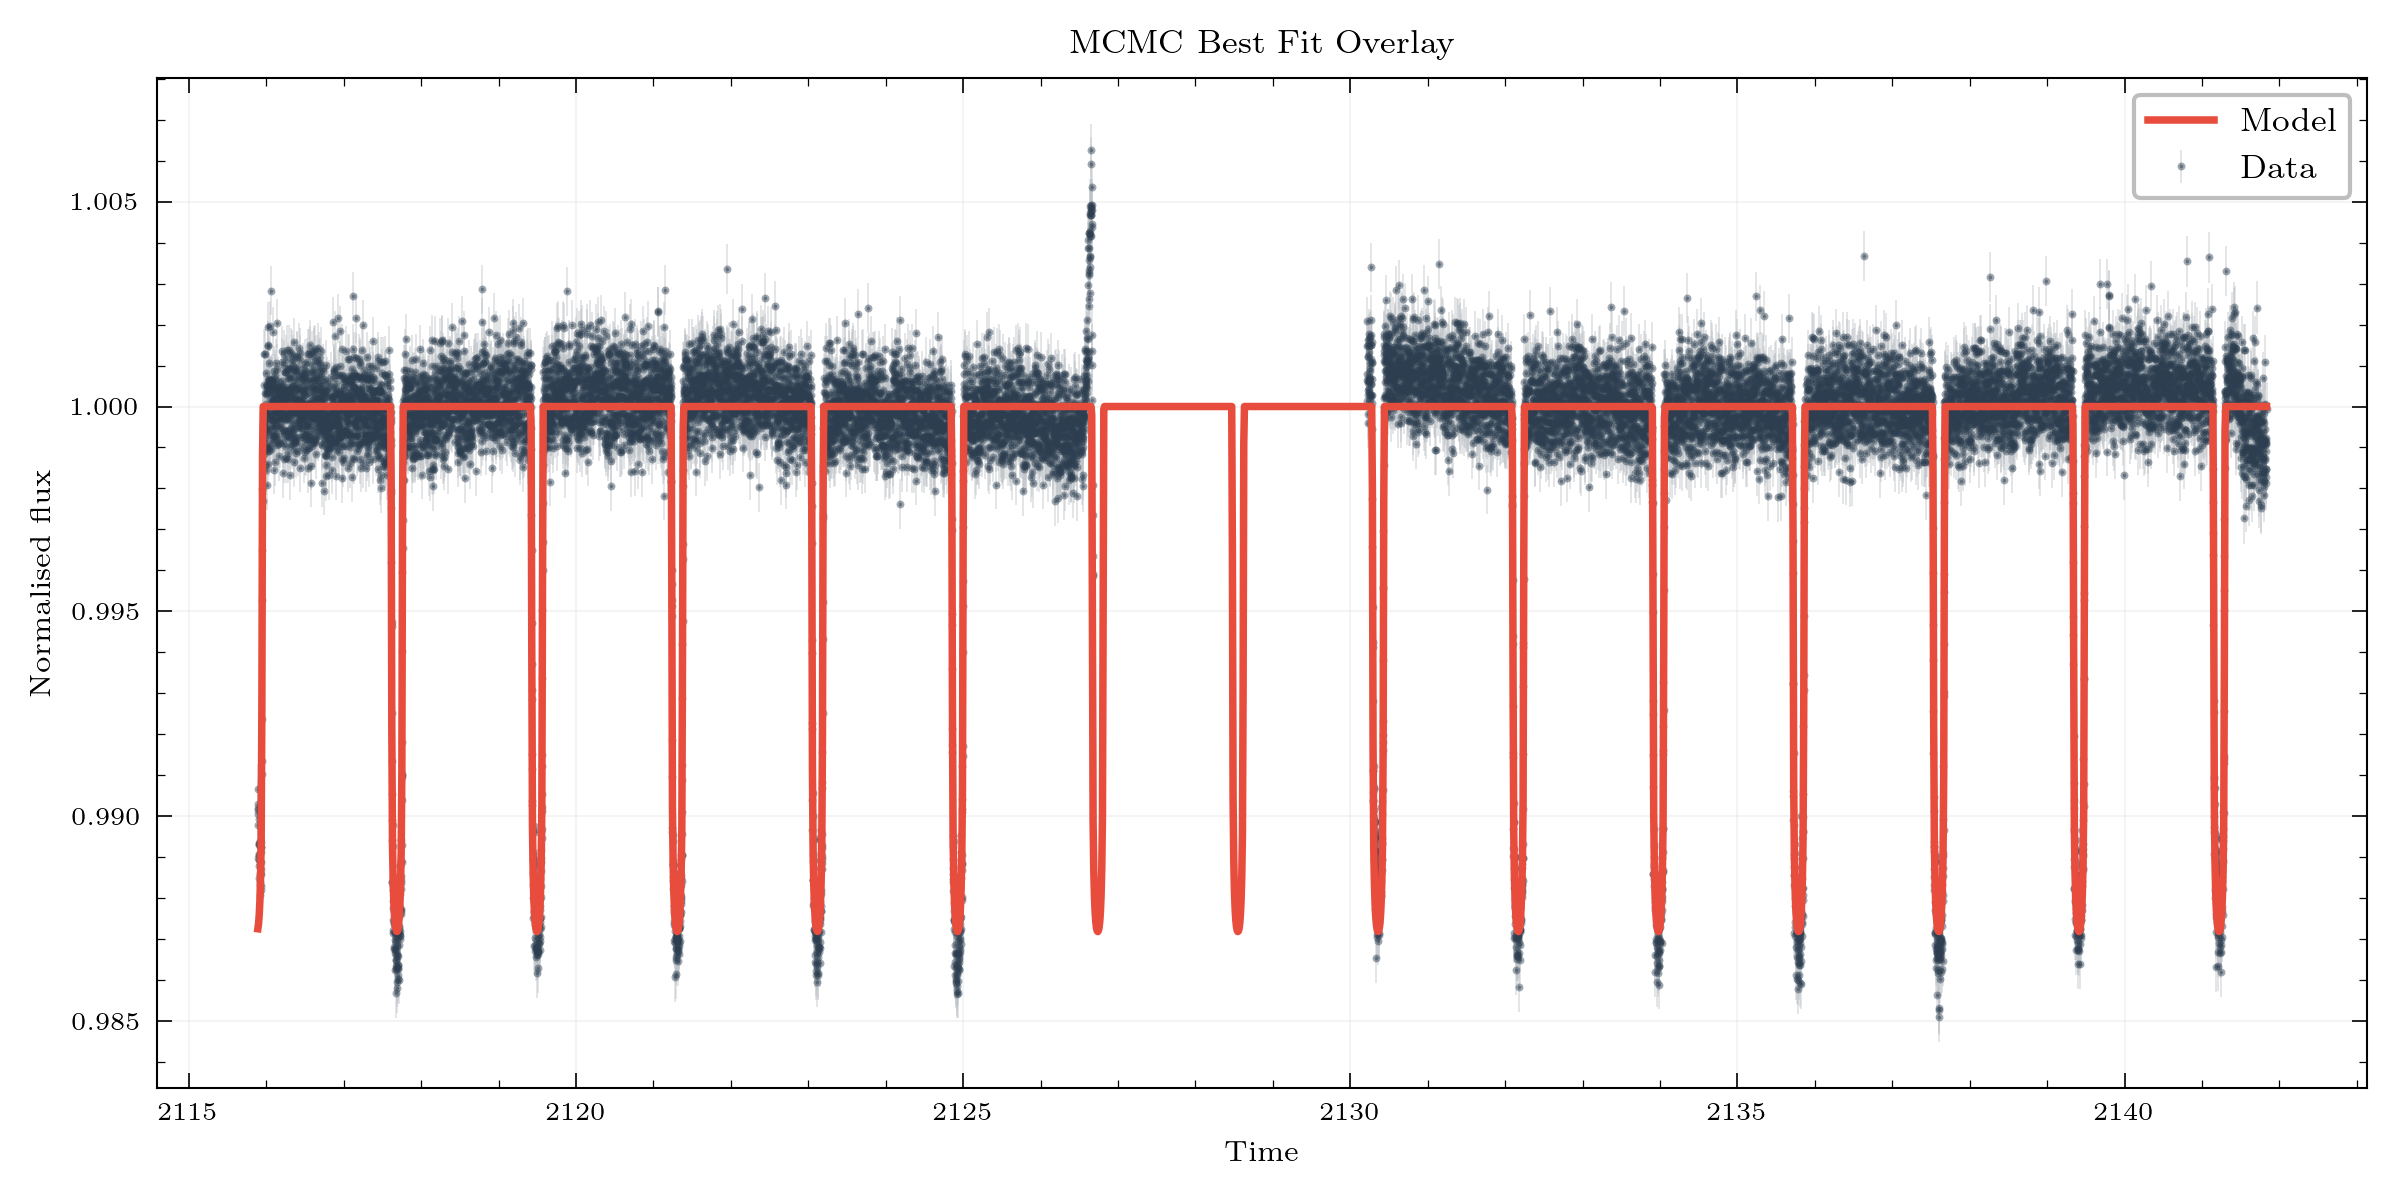

  [PASS] Lightcurve: line style
  [PASS] Lightcurve: errorbar style

8c. TransitPlotter.plot_mcmc_traces()
  [PASS] Traces: 6 subplots for 6 parameters


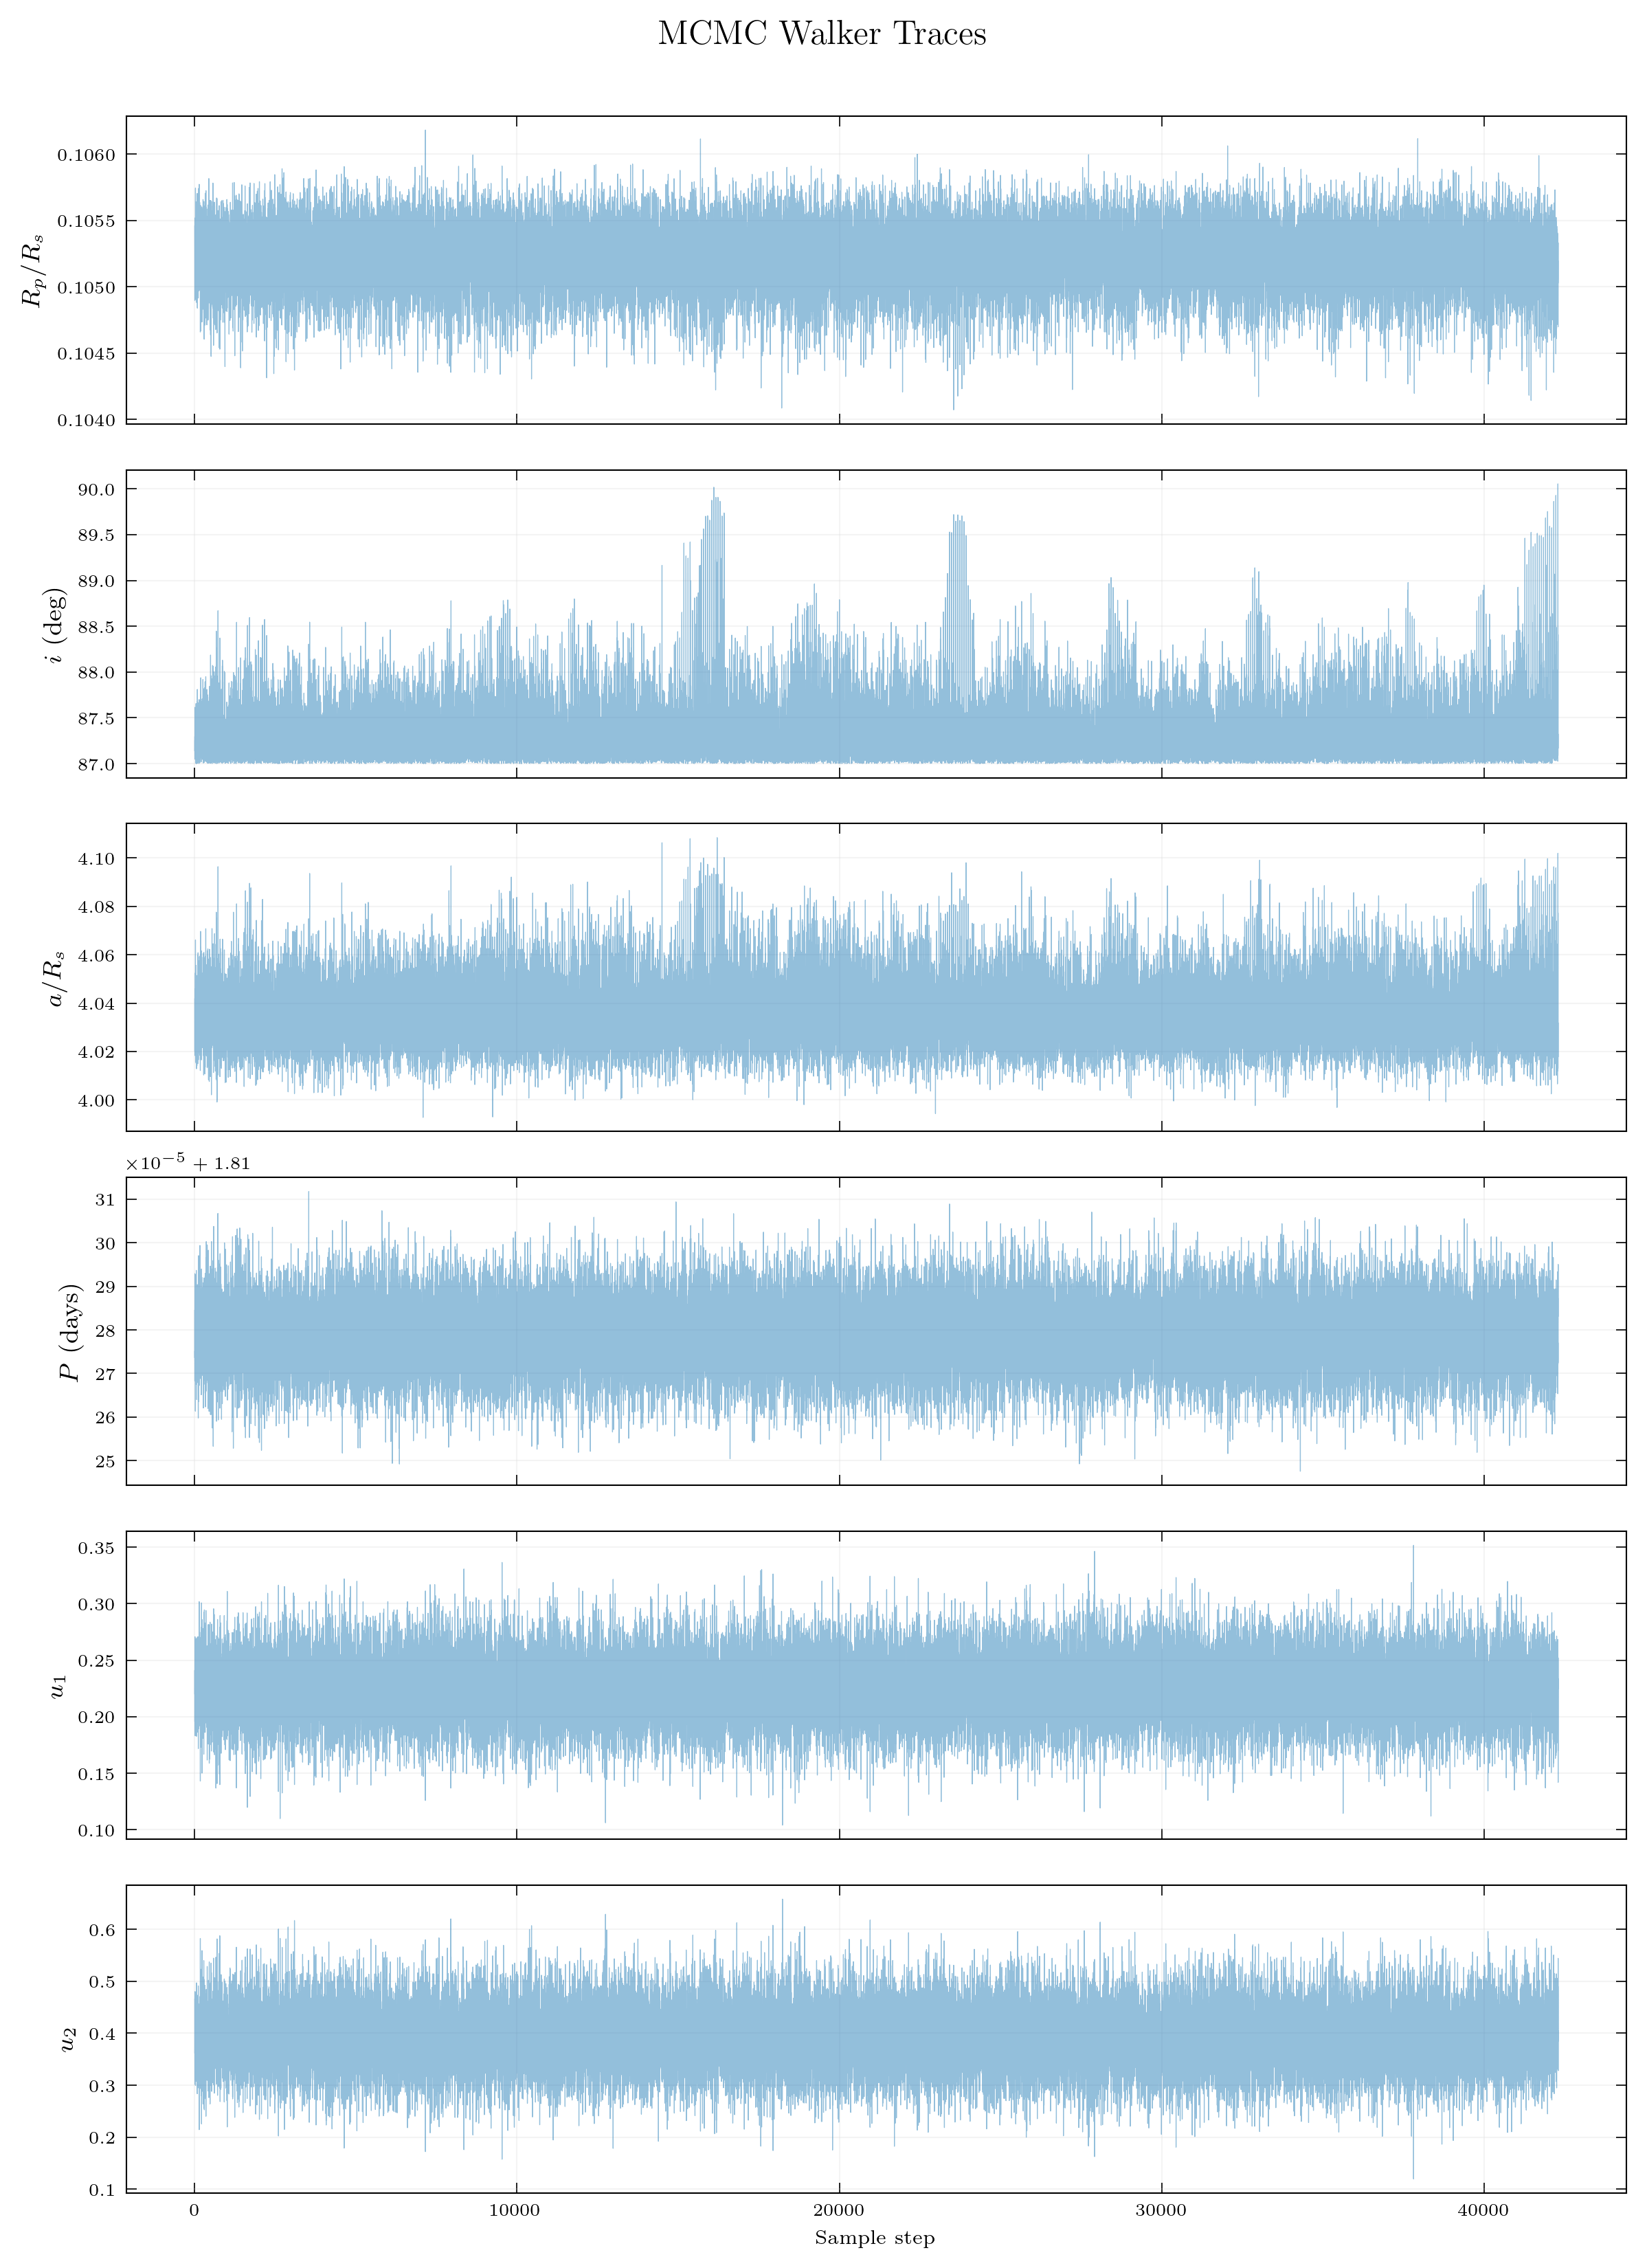

  [PASS] Traces: custom figsize 10×8

8d. TransitPlotter.plot_mcmc_corner()
  [PASS] Corner: 36 subplots (6×6 grid)


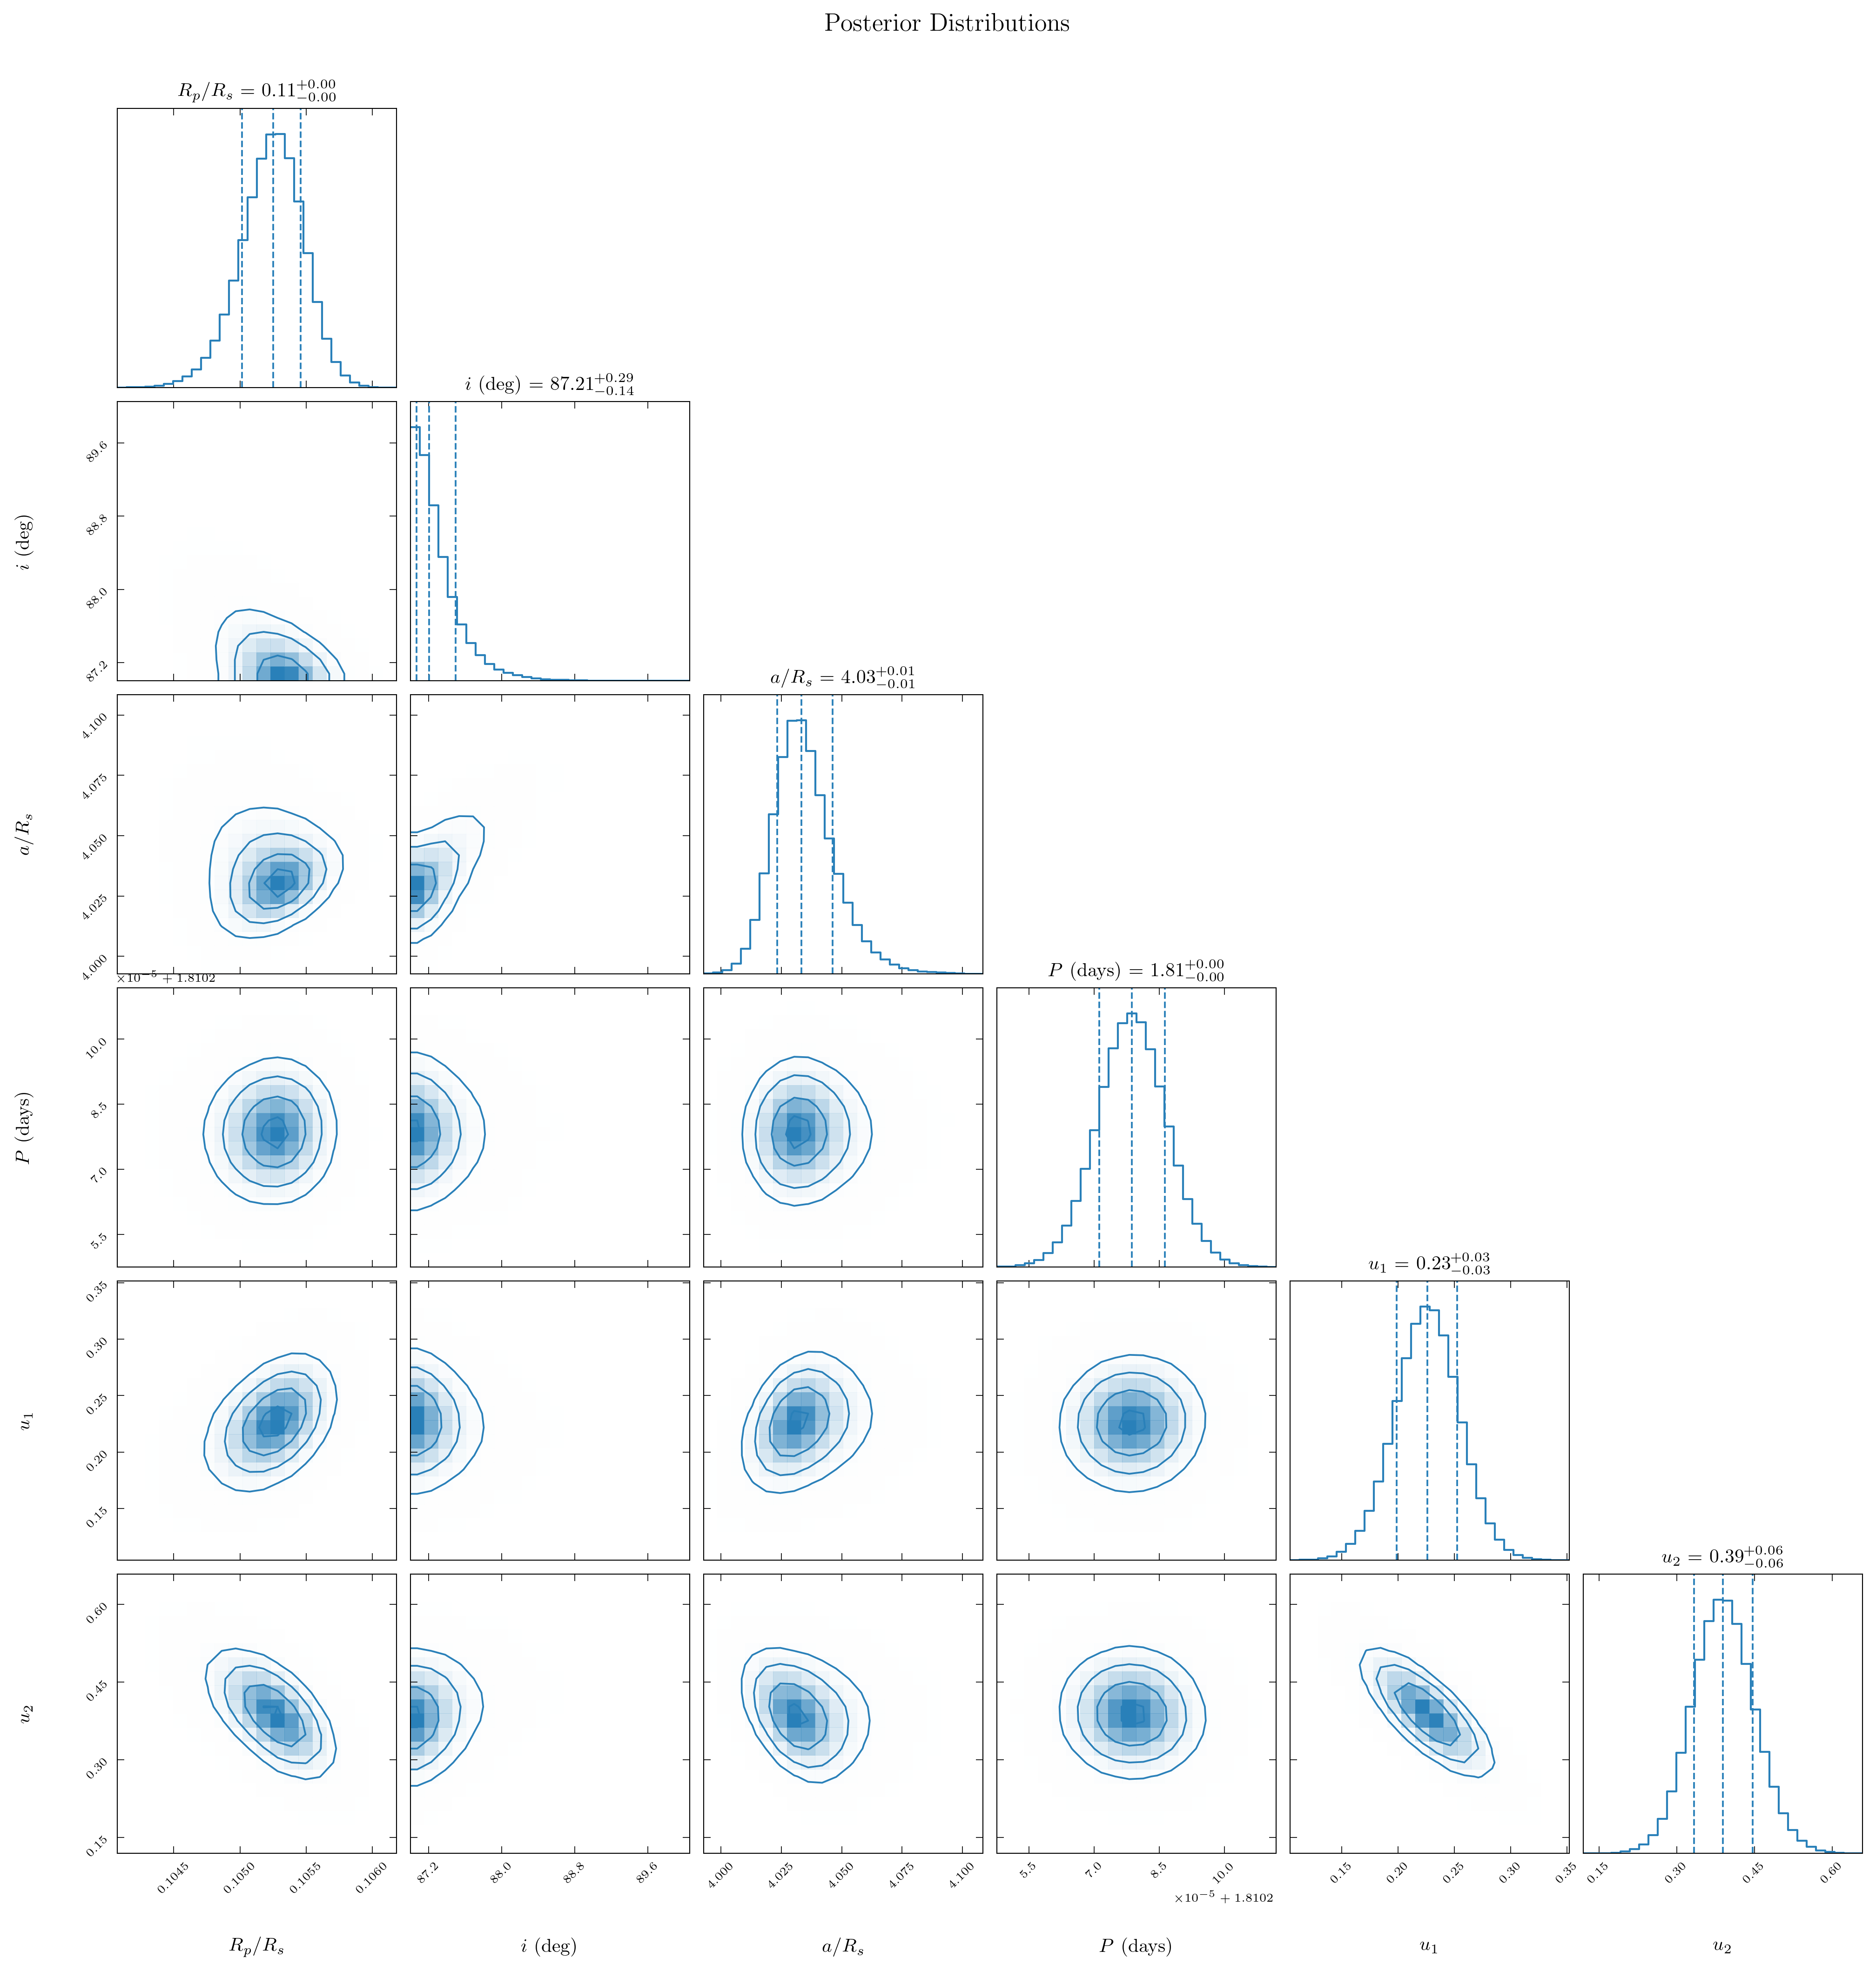

  [PASS] Corner: custom color + title

8e. RETURN TYPE CONSISTENCY
  [PASS] plot_lightcurve returns (Figure, ...)
  [PASS] plot_periodogram returns (Figure, ...)
  [PASS] plot_mcmc_traces returns (Figure, ...)
  [PASS] plot_mcmc_corner returns (Figure, ...)

✓ plotting.py (TransitPlotter) — all checks passed.


In [11]:
ok = lambda msg: print(f"  [PASS] {msg}")

# ── 8a. plot_periodogram ─────────────────────────────────────────────
print("=" * 60)
print("8a. TransitPlotter.plot_periodogram()")
print("=" * 60)

fig, ax = TransitPlotter.plot_periodogram(
    x=analyzer.periodogram.period.value,
    y=analyzer.periodogram.power.value,
    title="BLS Power Spectrum"
)
assert isinstance(fig, plt.Figure)
assert ax.get_xscale() == 'log'
ok("Periodogram (period mode, log-x)")
plt.show()
plt.close(fig)

fig, ax = TransitPlotter.plot_periodogram(
    x=analyzer.periodogram.period.value,
    y=analyzer.periodogram.power.value,
    xaxis_type='frequency'
)
assert ax.get_xscale() == 'linear'
ok("Periodogram (frequency mode, linear-x)")
plt.close(fig)

# ── 8b. plot_lightcurve — multiple styles ─────────────────────────────
print("\n" + "=" * 60)
print("8b. TransitPlotter.plot_lightcurve()")
print("=" * 60)

model_time, model_flux = fitter.get_best_model_curve(num_points=3000)

fig, ax = TransitPlotter.plot_lightcurve(
    time, flux, err=err,
    model_x=model_time, model_y=model_flux,
    style='scatter',
    title="MCMC Best Fit Overlay"
)
assert isinstance(fig, plt.Figure)
ok("Lightcurve: scatter + model + binning")
plt.show()
plt.close(fig)

fig, ax = TransitPlotter.plot_lightcurve(
    time, flux, style='line', title="Line Style"
)
ok("Lightcurve: line style")
plt.close(fig)

fig, ax = TransitPlotter.plot_lightcurve(
    time, flux, err=err, style='errorbar', title="Errorbar Style"
)
ok("Lightcurve: errorbar style")
plt.close(fig)

# ── 8c. plot_mcmc_traces ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("8c. TransitPlotter.plot_mcmc_traces()")
print("=" * 60)

fig, axes = TransitPlotter.plot_mcmc_traces(fitter.flat_samples, fitter.labels)
assert isinstance(fig, plt.Figure)
assert len(axes) == len(fitter.labels)
ok(f"Traces: {len(axes)} subplots for {len(fitter.labels)} parameters")
plt.show()
plt.close(fig)

fig, axes = TransitPlotter.plot_mcmc_traces(
    fitter.flat_samples, fitter.labels, figsize=(10, 8)
)
w, h = fig.get_size_inches()
assert abs(w - 10) < 0.1
ok(f"Traces: custom figsize {w:.0f}×{h:.0f}")
plt.close(fig)

# ── 8d. plot_mcmc_corner ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("8d. TransitPlotter.plot_mcmc_corner()")
print("=" * 60)

fig, axes = TransitPlotter.plot_mcmc_corner(fitter.flat_samples, fitter.labels)
assert isinstance(fig, plt.Figure)
assert axes.size == len(fitter.labels) ** 2
ok(f"Corner: {axes.size} subplots ({len(fitter.labels)}×{len(fitter.labels)} grid)")
plt.show()
plt.close(fig)

fig, axes = TransitPlotter.plot_mcmc_corner(
    fitter.flat_samples, fitter.labels, color='#e74c3c',
    title="Custom Corner"
)
ok("Corner: custom color + title")
plt.close(fig)

# ── 8e. Return type consistency ───────────────────────────────────────
print("\n" + "=" * 60)
print("8e. RETURN TYPE CONSISTENCY")
print("=" * 60)

for name, call in [
    ("plot_lightcurve", lambda: TransitPlotter.plot_lightcurve(time, flux)),
    ("plot_periodogram", lambda: TransitPlotter.plot_periodogram(
        analyzer.periodogram.period.value, analyzer.periodogram.power.value)),
    ("plot_mcmc_traces", lambda: TransitPlotter.plot_mcmc_traces(
        fitter.flat_samples, fitter.labels)),
    ("plot_mcmc_corner", lambda: TransitPlotter.plot_mcmc_corner(
        fitter.flat_samples, fitter.labels)),
]:
    result = call()
    assert isinstance(result, tuple) and len(result) == 2
    assert isinstance(result[0], plt.Figure)
    ok(f"{name} returns (Figure, ...)")
    plt.close(result[0])

print(f"\n✓ plotting.py (TransitPlotter) — all checks passed.")

---
### 9. Publication-Quality PDF Report (`reports.py`)
Single output file: ``generate_mcmc_report`` writes one DVR-style page (light curve, periodogram inset, folded transit, parameter table with **MCMC convergence** underneath, corner plot, traces). Optional ``locale=...`` override.


In [10]:
# ==========================================================
# 9. PDF Report — single combined DVR file (no catalog)
# ==========================================================
# Uses only ``generate_mcmc_report`` — do NOT call generate_catalog_report
# (removed) or expect filtered_df.

ok = lambda msg: print(f"  [PASS] {msg}")

report_gen = ReportGenerator(website_name="Exoplot", use_latex=True)
print(f"PDF output directory: {report_gen.results_dir}")
print(f"LaTeX rendering: {report_gen.use_latex}")

out_name = f"{analyzer.target_name.replace(' ', '_')}_DVR.pdf"
filepath = report_gen.generate_mcmc_report(out_name, analyzer, fitter)
assert filepath.exists()
ok(f"Single report written: {filepath.name} ({filepath.stat().st_size // 1024} KB)")

display(FileLink(str(filepath)))
print("\n✓ reports.py — single PDF generated.")


PDF output directory: /Users/simon.wtmn/Desktop/Exoplot_ENS/results
LaTeX rendering: True
  [PASS] Single report written: WASP_76_DVR.pdf (2493 KB)


/Users/simon.wtmn/Desktop/Exoplot_ENS/results/WASP_76_DVR.pdf


✓ reports.py — single PDF generated.
